In [ ]:
# Cell 1: Install kagglehub and download ECG dataset
!pip install -q kagglehub

import kagglehub

# Download latest version of ECG Heartbeat Categorization Dataset
path = kagglehub.dataset_download("shayanfazeli/heartbeat")
print("Dataset downloaded to:", path)

# List the files
import os
print("\nFiles in dataset:")
print(os.listdir(path))

100%|██████████| 98.8M/98.8M [00:05<00:00, 20.3MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/shayanfazeli/heartbeat/versions/1

Files in dataset:
['ptbdb_normal.csv', 'mitbih_train.csv', 'mitbih_test.csv', 'ptbdb_abnormal.csv']


In [ ]:
# Cell 2: Load StressLevelDataset
import pandas as pd
import os

# Check if file exists
if os.path.exists('/content/StressLevelDataset.csv'):
    stress_df = pd.read_csv('/content/StressLevelDataset.csv')
    print("Stress dataset loaded successfully.")
    print("Shape:", stress_df.shape)
    print("\nFirst 5 rows:")
    print(stress_df.head())
    print("\nTarget distribution (stress_level):")
    print(stress_df['stress_level'].value_counts())
else:
    print("Please upload StressLevelDataset.csv to /content/")

Please upload StressLevelDataset.csv to /content/


In [ ]:
# Cell 3: Load and explore StressLevelDataset
import pandas as pd

# Assuming the file is in the current directory (/content/)
stress_df = pd.read_csv('StressLevelDataset.csv')
print("Stress dataset shape:", stress_df.shape)
print("\nFirst 5 rows:")
print(stress_df.head())
print("\nColumn names:", stress_df.columns.tolist())
print("\nTarget distribution (stress_level):")
print(stress_df['stress_level'].value_counts())

Stress dataset shape: (1100, 12)

First 5 rows:
   anxiety_level  mental_health_history  depression  headache  sleep_quality  \
0             14                      0          11         2              2   
1             15                      1          15         5              1   
2             12                      1          14         2              2   
3             16                      1          15         4              4   
4             16                      0           7         2              5   

   breathing_problem  living_conditions  academic_performance  study_load  \
0                  4                  3                     3           2   
1                  4                  1                     1           4   
2                  2                  2                     2           3   
3                  3                  2                     2           4   
4                  1                  2                     4           3   

   futur

In [ ]:
# Cell 4: Download correct ECG dataset
import kagglehub
import os
import pandas as pd

# Correct dataset ID
correct_dataset = "shayanfazeli/heartbeat"

print("Downloading correct ECG dataset...")
ecg_path = kagglehub.dataset_download(correct_dataset)
print("Dataset downloaded to:", ecg_path)
print("Files in dataset:", os.listdir(ecg_path))

# Load the CSV files
train_df = pd.read_csv(os.path.join(ecg_path, 'mitbih_train.csv'), header=None)
test_df = pd.read_csv(os.path.join(ecg_path, 'mitbih_test.csv'), header=None)

print("\n✅ ECG data loaded successfully!")
print("Training data shape:", train_df.shape)
print("Test data shape:", test_df.shape)
print("\nFirst row (first 5 features + label):")
print("Features (first 5):", train_df.iloc[0, :5].values)
print("Label (last column):", train_df.iloc[0, -1])

Using Colab cache for faster access to the 'heartbeat' dataset.
Dataset downloaded to: /kaggle/input/heartbeat
Files in dataset: ['ptbdb_abnormal.csv', 'ptbdb_normal.csv', 'mitbih_test.csv', 'mitbih_train.csv']

✅ ECG data loaded successfully!
Training data shape: (87554, 188)
Test data shape: (21892, 188)

First row (first 5 features + label):
Features (first 5): [0.97794116 0.92647058 0.68137252 0.24509804 0.15441176]
Label (last column): 0.0


In [ ]:
# Cell 5: Clean stress dataset
import pandas as pd

# Reload if needed, but we already have stress_df
# If not in memory, load again:
# stress_df = pd.read_csv('/content/StressLevelDataset.csv')  # check exact filename

# Clean column names (strip spaces, rename mismatched ones)
stress_df.columns = stress_df.columns.str.strip()
stress_df.rename(columns={
    'study_lead': 'study_load',
    'future_career_concepts': 'future_career_concerns'
}, inplace=True)

print("Cleaned columns:")
print(stress_df.columns.tolist())
print("\nDataset shape:", stress_df.shape)
print("\nTarget distribution:")
print(stress_df['stress_level'].value_counts().sort_index())

Cleaned columns:
['anxiety_level', 'mental_health_history', 'depression', 'headache', 'sleep_quality', 'breathing_problem', 'living_conditions', 'academic_performance', 'study_load', 'future_career_concerns', 'extracurricular_activities', 'stress_level']

Dataset shape: (1100, 12)

Target distribution:
stress_level
0    373
1    358
2    369
Name: count, dtype: int64


In [ ]:
# Cell 4: Download correct ECG dataset
import kagglehub
import os
import pandas as pd

# Correct dataset ID
correct_dataset = "shayanfazeli/heartbeat"

print("Downloading correct ECG dataset...")
ecg_path = kagglehub.dataset_download(correct_dataset)
print("Dataset downloaded to:", ecg_path)
print("Files in dataset:", os.listdir(ecg_path))

# Load the CSV files
train_df = pd.read_csv(os.path.join(ecg_path, 'mitbih_train.csv'), header=None)
test_df = pd.read_csv(os.path.join(ecg_path, 'mitbih_test.csv'), header=None)

print("\n✅ ECG data loaded successfully!")
print("Training data shape:", train_df.shape)
print("Test data shape:", test_df.shape)
print("\nFirst row (first 5 features + label):")
print("Features (first 5):", train_df.iloc[0, :5].values)
print("Label (last column):", train_df.iloc[0, -1])

Using Colab cache for faster access to the 'heartbeat' dataset.
Dataset downloaded to: /kaggle/input/heartbeat
Files in dataset: ['ptbdb_abnormal.csv', 'ptbdb_normal.csv', 'mitbih_test.csv', 'mitbih_train.csv']

✅ ECG data loaded successfully!
Training data shape: (87554, 188)
Test data shape: (21892, 188)

First row (first 5 features + label):
Features (first 5): [0.97794116 0.92647058 0.68137252 0.24509804 0.15441176]
Label (last column): 0.0


In [ ]:
# Cell 5: Preprocess ECG dataset
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from collections import Counter

# Separate features and labels
X_train = train_df.iloc[:, :-1].values  # all rows, all but last column
y_train = train_df.iloc[:, -1].values   # last column

X_test = test_df.iloc[:, :-1].values
y_test = test_df.iloc[:, -1].values

print("Original train shape:", X_train.shape)
print("Original test shape:", X_test.shape)

# Normalize features (standardization)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Split training into train and validation (80/20)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print("\nAfter split:")
print("Train:", X_train.shape, Counter(y_train))
print("Validation:", X_val.shape, Counter(y_val))
print("Test:", X_test.shape, Counter(y_test))

# Reshape for 1D CNN (samples, timesteps, channels)
# We have 187 timesteps, 1 channel
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_val = X_val.reshape(X_val.shape[0], X_val.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print("\nFinal shapes for CNN:")
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Original train shape: (87554, 187)
Original test shape: (21892, 187)

After split:
Train: (70043, 187) Counter({np.float64(0.0): 57977, np.float64(4.0): 5145, np.float64(2.0): 4630, np.float64(1.0): 1778, np.float64(3.0): 513})
Validation: (17511, 187) Counter({np.float64(0.0): 14494, np.float64(4.0): 1286, np.float64(2.0): 1158, np.float64(1.0): 445, np.float64(3.0): 128})
Test: (21892, 187) Counter({np.float64(0.0): 18118, np.float64(4.0): 1608, np.float64(2.0): 1448, np.float64(1.0): 556, np.float64(3.0): 162})

Final shapes for CNN:
Train: (70043, 187, 1)
Validation: (17511, 187, 1)
Test: (21892, 187, 1)


In [ ]:
# Cell 5: Preprocess ECG dataset
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from collections import Counter

# Separate features and labels
X_train = train_df.iloc[:, :-1].values  # all rows, all but last column
y_train = train_df.iloc[:, -1].values   # last column

X_test = test_df.iloc[:, :-1].values
y_test = test_df.iloc[:, -1].values

print("Original train shape:", X_train.shape)
print("Original test shape:", X_test.shape)

# Normalize features (standardization)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Split training into train and validation (80/20)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print("\nAfter split:")
print("Train:", X_train.shape, Counter(y_train))
print("Validation:", X_val.shape, Counter(y_val))
print("Test:", X_test.shape, Counter(y_test))

# Reshape for 1D CNN (samples, timesteps, channels)
# We have 187 timesteps, 1 channel
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_val = X_val.reshape(X_val.shape[0], X_val.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print("\nFinal shapes for CNN:")
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Original train shape: (87554, 187)
Original test shape: (21892, 187)

After split:
Train: (70043, 187) Counter({np.float64(0.0): 57977, np.float64(4.0): 5145, np.float64(2.0): 4630, np.float64(1.0): 1778, np.float64(3.0): 513})
Validation: (17511, 187) Counter({np.float64(0.0): 14494, np.float64(4.0): 1286, np.float64(2.0): 1158, np.float64(1.0): 445, np.float64(3.0): 128})
Test: (21892, 187) Counter({np.float64(0.0): 18118, np.float64(4.0): 1608, np.float64(2.0): 1448, np.float64(1.0): 556, np.float64(3.0): 162})

Final shapes for CNN:
Train: (70043, 187, 1)
Validation: (17511, 187, 1)
Test: (21892, 187, 1)


In [ ]:
# Cell 6: Build 1D CNN for ECG Arrhythmia Detection
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# Compute class weights to handle imbalance
y_train_int = y_train.astype(int)
classes = np.unique(y_train_int)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train_int)
class_weight_dict = dict(zip(classes, class_weights))
print("Class weights:", class_weight_dict)

# Define model architecture
model = keras.Sequential([
    layers.Input(shape=(187, 1)),
    layers.Conv1D(filters=32, kernel_size=5, activation='relu', padding='same'),
    layers.MaxPooling1D(pool_size=2),
    layers.Conv1D(filters=64, kernel_size=5, activation='relu', padding='same'),
    layers.MaxPooling1D(pool_size=2),
    layers.Conv1D(filters=128, kernel_size=5, activation='relu', padding='same'),
    layers.MaxPooling1D(pool_size=2),
    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(5, activation='softmax')  # 5 classes
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Class weights: {np.int64(0): np.float64(0.2416234023837039), np.int64(1): np.float64(7.878852643419573), np.int64(2): np.float64(3.0256155507559397), np.int64(3): np.float64(27.307212475633527), np.int64(4): np.float64(2.722759961127308)}


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 187, 32)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 93, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 93, 64)         │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 46, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 46, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 23, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2944)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2944)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       376,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 429,189 (1.64 MB)

 Trainable params: 429,189 (1.64 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Cell 6: Build 1D CNN for ECG Arrhythmia Detection
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# Convert labels to int
y_train_int = y_train.astype(int)

# Compute class weights to handle imbalance
classes = np.unique(y_train_int)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train_int)
class_weight_dict = dict(zip(classes, class_weights))
print("Class weights:", class_weight_dict)

# Define model architecture
model = keras.Sequential([
    layers.Input(shape=(187, 1)),
    layers.Conv1D(filters=32, kernel_size=5, activation='relu', padding='same'),
    layers.MaxPooling1D(pool_size=2),
    layers.Conv1D(filters=64, kernel_size=5, activation='relu', padding='same'),
    layers.MaxPooling1D(pool_size=2),
    layers.Conv1D(filters=128, kernel_size=5, activation='relu', padding='same'),
    layers.MaxPooling1D(pool_size=2),
    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(5, activation='softmax')  # 5 classes
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Class weights: {np.int64(0): np.float64(0.2416234023837039), np.int64(1): np.float64(7.878852643419573), np.int64(2): np.float64(3.0256155507559397), np.int64(3): np.float64(27.307212475633527), np.int64(4): np.float64(2.722759961127308)}


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)               │ (None, 187, 32)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 93, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 93, 64)         │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 46, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 46, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 23, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2944)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2944)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       376,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 429,189 (1.64 MB)

 Trainable params: 429,189 (1.64 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Cell 7: Train ECG Model
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_ecg_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# Train the model
history = model.fit(
    X_train, y_train_int,
    validation_data=(X_val, y_val.astype(int)),
    epochs=30,
    batch_size=128,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

print("\n✅ Training complete! Best model saved as 'best_ecg_model.h5'")

Epoch 1/30
547/548 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.6508 - loss: 0.7940
Epoch 1: val_accuracy improved from None to 0.81617, saving model to best_ecg_model.h5



Epoch 1: finished saving model to best_ecg_model.h5
548/548 ━━━━━━━━━━━━━━━━━━━━ 76s 126ms/step - accuracy: 0.7371 - loss: 0.5800 - val_accuracy: 0.8162 - val_loss: 0.4631 - learning_rate: 0.0010
Epoch 2/30
547/548 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.8247 - loss: 0.4019
Epoch 2: val_accuracy improved from 0.81617 to 0.86723, saving model to best_ecg_model.h5



Epoch 2: finished saving model to best_ecg_model.h5
548/548 ━━━━━━━━━━━━━━━━━━━━ 69s 105ms/step - accuracy: 0.8333 - loss: 0.3739 - val_accuracy: 0.8672 - val_loss: 0.4218 - learning_rate: 0.0010
Epoch 3/30
547/548 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.8581 - loss: 0.3071
Epoch 3: val_accuracy improved from 0.86723 to 0.88242, saving model to best_ecg_model.h5



Epoch 3: finished saving model to best_ecg_model.h5
548/548 ━━━━━━━━━━━━━━━━━━━━ 79s 100ms/step - accuracy: 0.8602 - loss: 0.3054 - val_accuracy: 0.8824 - val_loss: 0.3418 - learning_rate: 0.0010
Epoch 4/30
547/548 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.8787 - loss: 0.2548
Epoch 4: val_accuracy improved from 0.88242 to 0.91137, saving model to best_ecg_model.h5



Epoch 4: finished saving model to best_ecg_model.h5
548/548 ━━━━━━━━━━━━━━━━━━━━ 80s 96ms/step - accuracy: 0.8815 - loss: 0.2515 - val_accuracy: 0.9114 - val_loss: 0.2647 - learning_rate: 0.0010
Epoch 5/30
547/548 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.8904 - loss: 0.2204
Epoch 5: val_accuracy improved from 0.91137 to 0.93547, saving model to best_ecg_model.h5


...


Epoch 20: finished saving model to best_ecg_model.h5
548/548 ━━━━━━━━━━━━━━━━━━━━ 53s 97ms/step - accuracy: 0.9571 - loss: 0.0727 - val_accuracy: 0.9682 - val_loss: 0.1070 - learning_rate: 5.0000e-04
Epoch 21/30
547/548 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.9601 - loss: 0.0700
Epoch 21: val_accuracy did not improve from 0.96825
548/548 ━━━━━━━━━━━━━━━━━━━━ 54s 98ms/step - accuracy: 0.9611 - loss: 0.0691 - val_accuracy: 0.9677 - val_loss: 0.1059 - learning_rate: 5.0000e-04
Epoch 22/30
547/548 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.9572 - loss: 0.0714
Epoch 22: val_accuracy improved from 0.96825 to 0.96945, saving model to best_ecg_model.h5



Epoch 22: finished saving model to best_ecg_model.h5
548/548 ━━━━━━━━━━━━━━━━━━━━ 81s 97ms/step - accuracy: 0.9582 - loss: 0.0691 - val_accuracy: 0.9694 - val_loss: 0.1051 - learning_rate: 5.0000e-04
Epoch 23/30
547/548 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.9587 - loss: 0.0712
Epoch 23: val_accuracy did not improve from 0.96945
548/548 ━━━━━━━━━━━━━━━━━━━━ 81s 95ms/step - accuracy: 0.9559 - loss: 0.0739 - val_accuracy: 0.9611 - val_loss: 0.1112 - learning_rate: 5.0000e-04
Epoch 24/30
547/548 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.9627 - loss: 0.0661
Epoch 24: val_accuracy improved from 0.96945 to 0.97350, saving model to best_ecg_model.h5



Epoch 24: finished saving model to best_ecg_model.h5
548/548 ━━━━━━━━━━━━━━━━━━━━ 53s 98ms/step - accuracy: 0.9610 - loss: 0.0641 - val_accuracy: 0.9735 - val_loss: 0.0913 - learning_rate: 5.0000e-04
Epoch 25/30
547/548 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.9621 - loss: 0.0626
Epoch 25: val_accuracy did not improve from 0.97350
548/548 ━━━━━━━━━━━━━━━━━━━━ 55s 101ms/step - accuracy: 0.9627 - loss: 0.0625 - val_accuracy: 0.9670 - val_loss: 0.1054 - learning_rate: 5.0000e-04
Epoch 26/30
547/548 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.9628 - loss: 0.0630
Epoch 26: val_accuracy did not improve from 0.97350
548/548 ━━━━━━━━━━━━━━━━━━━━ 55s 100ms/step - accuracy: 0.9614 - loss: 0.0634 - val_accuracy: 0.9710 - val_loss: 0.0961 - learning_rate: 5.0000e-04
Epoch 27/30
547/548 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.9635 - loss: 0.0614
Epoch 27: val_accuracy did not improve from 0.97350
548/548 ━━━━━━━━━━━━━━━━━━━━ 82s 100ms/step - accuracy: 0.9605 - loss: 0.0670 - val


Epoch 28: finished saving model to best_ecg_model.h5
548/548 ━━━━━━━━━━━━━━━━━━━━ 84s 103ms/step - accuracy: 0.9626 - loss: 0.0624 - val_accuracy: 0.9742 - val_loss: 0.0869 - learning_rate: 5.0000e-04
Epoch 29/30
547/548 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.9678 - loss: 0.0529
Epoch 29: val_accuracy did not improve from 0.97424
548/548 ━━━━━━━━━━━━━━━━━━━━ 52s 94ms/step - accuracy: 0.9661 - loss: 0.0550 - val_accuracy: 0.9671 - val_loss: 0.1074 - learning_rate: 5.0000e-04
Epoch 30/30
547/548 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.9632 - loss: 0.0582
Epoch 30: val_accuracy improved from 0.97424 to 0.97436, saving model to best_ecg_model.h5



Epoch 30: finished saving model to best_ecg_model.h5
548/548 ━━━━━━━━━━━━━━━━━━━━ 55s 99ms/step - accuracy: 0.9648 - loss: 0.0588 - val_accuracy: 0.9744 - val_loss: 0.0894 - learning_rate: 5.0000e-04
Restoring model weights from the end of the best epoch: 28.

✅ Training complete! Best model saved as 'best_ecg_model.h5'


Test Accuracy: 0.9731
Test Loss: 0.0943
685/685 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step

Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      0.98      0.99     18118
           S       0.62      0.86      0.72       556
           V       0.95      0.96      0.95      1448
           F       0.65      0.88      0.75       162
           Q       0.98      0.99      0.99      1608

    accuracy                           0.97     21892
   macro avg       0.84      0.94      0.88     21892
weighted avg       0.98      0.97      0.97     21892



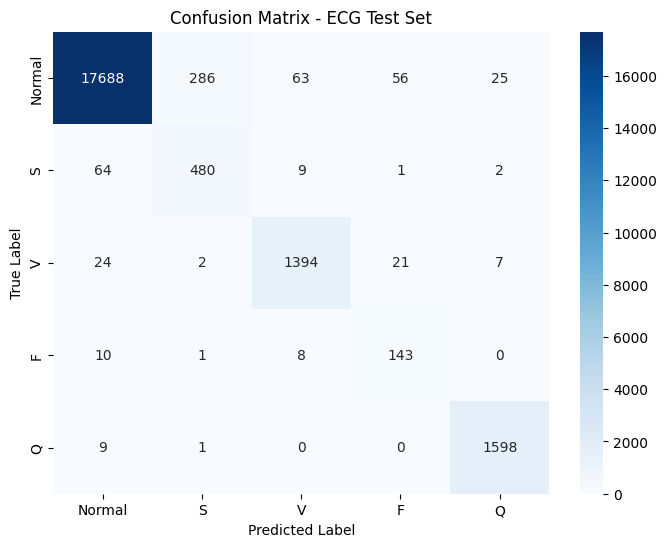

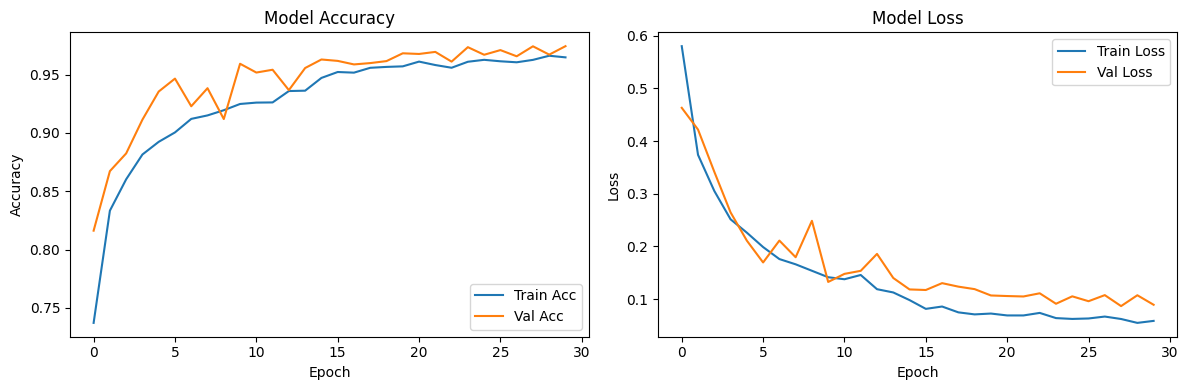

In [ ]:
# Cell 8: Evaluate ECG Model
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tensorflow.keras.models import load_model

# Load the best model
best_model = load_model('best_ecg_model.h5')

# Evaluate on test set
y_test_int = y_test.astype(int)
test_loss, test_acc = best_model.evaluate(X_test, y_test_int, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Predict on test set
y_pred_probs = best_model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test_int, y_pred, target_names=['Normal', 'S', 'V', 'F', 'Q']))

# Confusion matrix
cm = confusion_matrix(y_test_int, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'S', 'V', 'F', 'Q'],
            yticklabels=['Normal', 'S', 'V', 'F', 'Q'])
plt.title('Confusion Matrix - ECG Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Plot training history
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Cell 9: Preprocess Stress Dataset
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from collections import Counter

# Check for missing values
print("Missing values:\n", stress_df.isnull().sum())

# Separate features and target
X_stress = stress_df.drop('stress_level', axis=1)
y_stress = stress_df['stress_level']

# Check class distribution
print("\nClass distribution:\n", y_stress.value_counts())

# Split into train (70%), val (15%), test (15%)
X_temp, X_test_stress, y_temp, y_test_stress = train_test_split(
    X_stress, y_stress, test_size=0.15, random_state=42, stratify=y_stress
)
X_train_stress, X_val_stress, y_train_stress, y_val_stress = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp  # 0.1765 of 85% = 15% of total
)

print(f"\nTrain: {X_train_stress.shape}, Val: {X_val_stress.shape}, Test: {X_test_stress.shape}")

# Standardize features
scaler_stress = StandardScaler()
X_train_stress = scaler_stress.fit_transform(X_train_stress)
X_val_stress = scaler_stress.transform(X_val_stress)
X_test_stress = scaler_stress.transform(X_test_stress)

print("\nScaling complete.")
print("First few rows of scaled training features:\n", X_train_stress[:2])

Missing values:
 anxiety_level                 0
mental_health_history         0
depression                    0
headache                      0
sleep_quality                 0
breathing_problem             0
living_conditions             0
academic_performance          0
study_load                    0
future_career_concerns        0
extracurricular_activities    0
stress_level                  0
dtype: int64

Class distribution:
 stress_level
0    373
2    369
1    358
Name: count, dtype: int64

Train: (769, 11), Val: (166, 11), Test: (165, 11)

Scaling complete.
First few rows of scaled training features:
 [[-0.00713067 -0.96800192  0.19690976 -0.36468548 -0.52105217  0.91133657
   0.41279087  0.13565528 -0.45135773  0.24671171  0.16448853]
 [-0.00713067  1.03305581 -0.06215543 -0.36468548 -0.52105217 -0.5411356
  -0.47888379  0.13565528 -0.45135773  0.24671171  0.16448853]]


Validation Accuracy: 0.8373
Test Accuracy: 0.8545

Classification Report (Test Set):
              precision    recall  f1-score   support

         Low       0.83      0.79      0.81        56
    Moderate       0.92      0.89      0.91        54
        High       0.82      0.89      0.85        55

    accuracy                           0.85       165
   macro avg       0.86      0.86      0.86       165
weighted avg       0.86      0.85      0.85       165



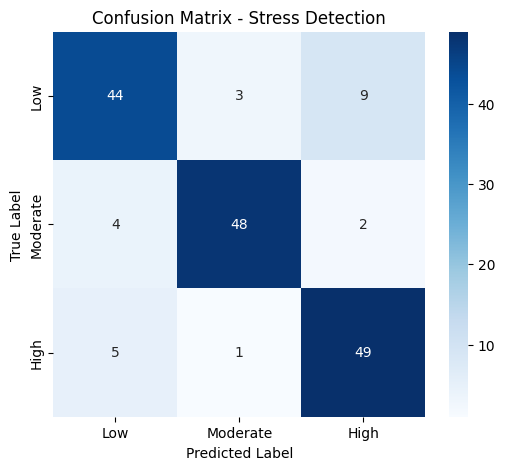


Top 5 Important Features:
                       feature  importance
3                     headache    0.157537
2                   depression    0.152347
7         academic_performance    0.135717
10  extracurricular_activities    0.129255
9       future_career_concerns    0.125505


In [ ]:
# Cell 10: Train Random Forest for Stress Detection
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    class_weight='balanced'  # handle class imbalance
)

rf_model.fit(X_train_stress, y_train_stress)

# Evaluate on validation set
y_val_pred = rf_model.predict(X_val_stress)
val_acc = accuracy_score(y_val_stress, y_val_pred)
print(f"Validation Accuracy: {val_acc:.4f}")

# Evaluate on test set
y_test_pred = rf_model.predict(X_test_stress)
test_acc = accuracy_score(y_test_stress, y_test_pred)
print(f"Test Accuracy: {test_acc:.4f}")

# Classification report
print("\nClassification Report (Test Set):")
print(classification_report(y_test_stress, y_test_pred, target_names=['Low', 'Moderate', 'High']))

# Confusion matrix
cm = confusion_matrix(y_test_stress, y_test_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'Moderate', 'High'],
            yticklabels=['Low', 'Moderate', 'High'])
plt.title('Confusion Matrix - Stress Detection')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Feature importance
feature_importance = pd.DataFrame({
    'feature': X_stress.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 5 Important Features:")
print(feature_importance.head())

In [ ]:
# Cell 11: XGBoost with GridSearchCV
!pip install -q xgboost

import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

# Define XGBoost model
xgb_model = xgb.XGBClassifier(objective='multi:softprob', num_class=3, random_state=42)

# Hyperparameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Grid search with cross-validation (using training set only, to avoid leaking test)
grid_search = GridSearchCV(
    xgb_model, param_grid, cv=5, scoring='accuracy',
    verbose=1, n_jobs=-1
)
grid_search.fit(X_train_stress, y_train_stress)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation accuracy: {:.4f}".format(grid_search.best_score_))

# Evaluate on validation and test
best_xgb = grid_search.best_estimator_
y_val_pred = best_xgb.predict(X_val_stress)
y_test_pred = best_xgb.predict(X_test_stress)

val_acc = accuracy_score(y_val_stress, y_val_pred)
test_acc = accuracy_score(y_test_stress, y_test_pred)
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

print("\nClassification Report (Test Set):")
print(classification_report(y_test_stress, y_test_pred, target_names=['Low', 'Moderate', 'High']))

# Feature importance
importances = best_xgb.feature_importances_
features = X_stress.columns
sorted_idx = np.argsort(importances)[::-1][:5]
print("\nTop 5 Important Features:")
for i in sorted_idx:
    print(f"{features[i]}: {importances[i]:.4f}")

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 100, 'subsample': 1.0}
Best cross-validation accuracy: 0.8921
Validation Accuracy: 0.8554
Test Accuracy: 0.8727

Classification Report (Test Set):
              precision    recall  f1-score   support

         Low       0.89      0.84      0.86        56
    Moderate       0.88      0.91      0.89        54
        High       0.86      0.87      0.86        55

    accuracy                           0.87       165
   macro avg       0.87      0.87      0.87       165
weighted avg       0.87      0.87      0.87       165


Top 5 Important Features:
academic_performance: 0.2828
future_career_concerns: 0.2374
depression: 0.1455
extracurricular_activities: 0.0871
headache: 0.0782


In [ ]:
# Cell 12: Neural Network for Stress Detection
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder

# Encode labels (0,1,2)
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train_stress)
y_val_enc = le.transform(y_val_stress)
y_test_enc = le.transform(y_test_stress)

# One-hot encode for neural network
y_train_cat = to_categorical(y_train_enc, 3)
y_val_cat = to_categorical(y_val_enc, 3)
y_test_cat = to_categorical(y_test_enc, 3)

# Build model
nn_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_stress.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(3, activation='softmax')
])

nn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train
history = nn_model.fit(
    X_train_stress, y_train_cat,
    validation_data=(X_val_stress, y_val_cat),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# Evaluate
loss, acc = nn_model.evaluate(X_test_stress, y_test_cat, verbose=0)
print(f"Test Accuracy: {acc:.4f}")

# Predict and classification report
y_pred_prob = nn_model.predict(X_test_stress)
y_pred = np.argmax(y_pred_prob, axis=1)
print("\nClassification Report (Test Set):")
print(classification_report(y_test_enc, y_pred, target_names=['Low', 'Moderate', 'High']))

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - accuracy: 0.5683 - loss: 1.0790 - val_accuracy: 0.6325 - val_loss: 0.7892
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7893 - loss: 0.5910 - val_accuracy: 0.6867 - val_loss: 0.6373
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8622 - loss: 0.4432 - val_accuracy: 0.7831 - val_loss: 0.5693
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8544 - loss: 0.4288 - val_accuracy: 0.8133 - val_loss: 0.5221
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8674 - loss: 0.3885 - val_accuracy: 0.8253 - val_loss: 0.4740
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8700 - loss: 0.3912 - val_accuracy: 0.8434 - val_loss: 0.4325
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8895 - loss: 0.3203 - val_accuracy: 0.8434 - val_loss: 0.4111
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8700 - loss: 0.3613 - val_accuracy: 0.8434 - val_l

In [ ]:
# Cell 13: Save Stress Model and Scaler
import joblib

# Save the best XGBoost model (from grid search)
joblib.dump(best_xgb, 'best_stress_model.pkl')

# Save the scaler used for stress features
joblib.dump(scaler_stress, 'stress_scaler.pkl')

print("✅ Stress model and scaler saved.")

✅ Stress model and scaler saved.


In [ ]:
# Cell 16: Stacking Ensemble
import numpy as np
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# Base models
base_models = [
    ('rf', RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)),
    ('xgb', XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42))
]

# Meta model
meta_model = LogisticRegression(max_iter=1000, random_state=42)

# Stacking classifier with 5‑fold cross‑validation
stacking_clf = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,
    stack_method='predict_proba'
)

# Train
stacking_clf.fit(X_train_stress, y_train_stress)

# Evaluate
y_val_pred = stacking_clf.predict(X_val_stress)
y_test_pred = stacking_clf.predict(X_test_stress)

val_acc = accuracy_score(y_val_stress, y_val_pred)
test_acc = accuracy_score(y_test_stress, y_test_pred)

print(f"Stacking Validation Accuracy: {val_acc:.4f}")
print(f"Stacking Test Accuracy: {test_acc:.4f}")

print("\nClassification Report (Test Set):")
print(classification_report(y_test_stress, y_test_pred, target_names=['Low', 'Moderate', 'High']))

Stacking Validation Accuracy: 0.8554
Stacking Test Accuracy: 0.8606

Classification Report (Test Set):
              precision    recall  f1-score   support

         Low       0.84      0.77      0.80        56
    Moderate       0.92      0.89      0.91        54
        High       0.82      0.93      0.87        55

    accuracy                           0.86       165
   macro avg       0.86      0.86      0.86       165
weighted avg       0.86      0.86      0.86       165



In [ ]:
# Cell 17: Load stress competition dataset
import pandas as pd
import os

# Check if files exist
if os.path.exists('/content/train.csv'):
    train_stress = pd.read_csv('/content/train.csv')
    print("Training data loaded. Shape:", train_stress.shape)
    print("\nFirst 5 rows:")
    print(train_stress.head())
    print("\nColumn names:")
    print(train_stress.columns.tolist())
    print("\nTarget column value counts (if present):")
    # Usually the target is 'Stress' or 'stress_level'
    target_cols = [col for col in train_stress.columns if 'stress' in col.lower()]
    if target_cols:
        print(train_stress[target_cols[0]].value_counts())
    else:
        print("No column containing 'stress' found. Column names are:", train_stress.columns.tolist())
else:
    print("Please upload train.csv first.")

Training data loaded. Shape: (1986, 117)

First 5 rows:
   post_id      subreddit post_id.1 sentence_range  \
0     2092         stress    8b9j8h         (0, 5)   
1     1567       homeless    8cprrd         (2, 7)   
2     1550           ptsd    63nmo1        (5, 10)   
3     2785           ptsd    9vkbbr         [0, 5]   
4     1936  relationships    7pdcp5         (0, 5)   

                                                text     id  label  \
0  Hello, You are invited to complete a survey fo...   6319      0   
1  I want to know about your story, how you got t...  42996      0   
2  Have any of you requested accommodations throu...  34744      0   
3  Whenever I have a reaction or meltdown, he alw...    614      1   
4  Throwaway because this is an embarrassing issu...  14399      1   

   confidence  social_timestamp  social_karma  ...  lex_dal_min_pleasantness  \
0    1.000000        1523381550             1  ...                     1.125   
1    0.800000        1523903160       

In [ ]:
# Cell 18: Explore the competition dataset
import pandas as pd
import numpy as np

# Load training data
train_df = pd.read_csv('/content/train.csv')
print("Shape:", train_df.shape)
print("\nColumns:", train_df.columns.tolist())
print("\nTarget distribution (label):")
print(train_df['label'].value_counts())
print(f"\nTarget balance: {train_df['label'].mean():.3f} (1 = stress)")

# Check for missing values
print("\nMissing values per column (top 10):")
print(train_df.isnull().sum().sort_values(ascending=False).head(10))

# Quick look at feature types
print("\nData types:")
print(train_df.dtypes.value_counts())

# Drop columns that are not numeric or are identifiers
# Keep only numeric features (excluding identifiers)
id_cols = ['post_id', 'post_id.1', 'id', 'sentence_range', 'text']
feature_cols = [col for col in train_df.columns if col not in id_cols + ['label']]
print(f"\nNumber of potential features: {len(feature_cols)}")

Shape: (1986, 117)

Columns: ['post_id', 'subreddit', 'post_id.1', 'sentence_range', 'text', 'id', 'label', 'confidence', 'social_timestamp', 'social_karma', 'syntax_ari', 'lex_liwc_WC', 'lex_liwc_Analytic', 'lex_liwc_Clout', 'lex_liwc_Authentic', 'lex_liwc_Tone', 'lex_liwc_WPS', 'lex_liwc_Sixltr', 'lex_liwc_Dic', 'lex_liwc_function', 'lex_liwc_pronoun', 'lex_liwc_ppron', 'lex_liwc_i', 'lex_liwc_we', 'lex_liwc_you', 'lex_liwc_shehe', 'lex_liwc_they', 'lex_liwc_ipron', 'lex_liwc_article', 'lex_liwc_prep', 'lex_liwc_auxverb', 'lex_liwc_adverb', 'lex_liwc_conj', 'lex_liwc_negate', 'lex_liwc_verb', 'lex_liwc_adj', 'lex_liwc_compare', 'lex_liwc_interrog', 'lex_liwc_number', 'lex_liwc_quant', 'lex_liwc_affect', 'lex_liwc_posemo', 'lex_liwc_negemo', 'lex_liwc_anx', 'lex_liwc_anger', 'lex_liwc_sad', 'lex_liwc_social', 'lex_liwc_family', 'lex_liwc_friend', 'lex_liwc_female', 'lex_liwc_male', 'lex_liwc_cogproc', 'lex_liwc_insight', 'lex_liwc_cause', 'lex_liwc_discrep', 'lex_liwc_tentat', 'lex_li

Kept 110 numeric features out of 116
Train shape: (1588, 110)
Val shape: (398, 110)
Train class distribution: [748 840]
Val class distribution: [188 210]

Validation Accuracy: 0.7789

Classification Report (Validation):
              precision    recall  f1-score   support

   No Stress       0.77      0.76      0.76       188
      Stress       0.79      0.80      0.79       210

    accuracy                           0.78       398
   macro avg       0.78      0.78      0.78       398
weighted avg       0.78      0.78      0.78       398



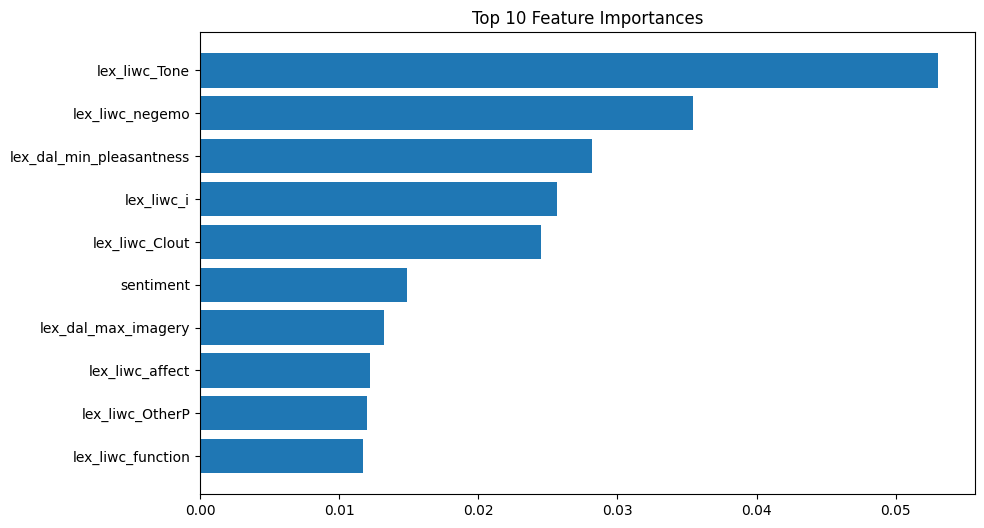

In [ ]:
# Cell 19: XGBoost without early stopping (simpler)
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# Load data
train_df = pd.read_csv('/content/train.csv')

# Identify numeric columns only (excluding identifiers and non‑numeric)
id_cols = ['post_id', 'post_id.1', 'id', 'sentence_range', 'text', 'subreddit']
feature_cols = [col for col in train_df.columns if col not in id_cols and col != 'label' and pd.api.types.is_numeric_dtype(train_df[col])]
print(f"Kept {len(feature_cols)} numeric features out of {len(train_df.columns)-1}")

X = train_df[feature_cols].copy()
y = train_df['label'].copy()

# Fill missing values with median
X = X.fillna(X.median())

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)
print("Train shape:", X_train.shape)
print("Val shape:", X_val.shape)
print("Train class distribution:", np.bincount(y_train))
print("Val class distribution:", np.bincount(y_val))

# XGBoost (no early stopping)
model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

model.fit(X_train, y_train)

# Evaluate on validation
y_val_pred = model.predict(X_val)
val_acc = accuracy_score(y_val, y_val_pred)
print(f"\nValidation Accuracy: {val_acc:.4f}")

print("\nClassification Report (Validation):")
print(classification_report(y_val, y_val_pred, target_names=['No Stress', 'Stress']))

# Feature importance
importances = model.feature_importances_
indices = np.argsort(importances)[-10:]
plt.figure(figsize=(10,6))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), [feature_cols[i] for i in indices])
plt.title('Top 10 Feature Importances')
plt.show()

In [ ]:
# Cell 20.1: Fine‑tuned XGBoost with RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# Use the same split as before (X_train_stress, X_test_stress, etc.)
param_dist = {
    'n_estimators': [100, 150, 200, 250, 300],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.03, 0.05, 0.07, 0.1],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2, 0.3],
    'reg_alpha': [0, 0.1, 0.5, 1],
    'reg_lambda': [0.5, 1, 1.5, 2]
}

xgb = XGBClassifier(objective='multi:softprob', num_class=3, random_state=42, eval_metric='mlogloss')

random_search = RandomizedSearchCV(
    xgb, param_distributions=param_dist,
    n_iter=60, cv=5, scoring='accuracy',
    n_jobs=-1, random_state=42, verbose=2
)

random_search.fit(X_train_stress, y_train_stress)

print("Best parameters:", random_search.best_params_)
print("Best CV accuracy: {:.4f}".format(random_search.best_score_))

best_xgb = random_search.best_estimator_
y_test_pred = best_xgb.predict(X_test_stress)
test_acc = accuracy_score(y_test_stress, y_test_pred)
print("Test accuracy: {:.4f}".format(test_acc))

print("\nClassification Report (Test):")
print(classification_report(y_test_stress, y_test_pred, target_names=['Low', 'Moderate', 'High']))

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best parameters: {'subsample': 0.6, 'reg_lambda': 1.5, 'reg_alpha': 0.5, 'n_estimators': 150, 'max_depth': 7, 'learning_rate': 0.03, 'gamma': 0.1, 'colsample_bytree': 0.9}
Best CV accuracy: 0.8882
Test accuracy: 0.8485

Classification Report (Test):
              precision    recall  f1-score   support

         Low       0.84      0.77      0.80        56
    Moderate       0.92      0.87      0.90        54
        High       0.79      0.91      0.85        55

    accuracy                           0.85       165
   macro avg       0.85      0.85      0.85       165
weighted avg       0.85      0.85      0.85       165



In [ ]:
# Cell 20.2: LightGBM
!pip install -q lightgbm

import lightgbm as lgb
from sklearn.metrics import accuracy_score, classification_report

# Convert data
train_data = lgb.Dataset(X_train_stress, label=y_train_stress)
val_data = lgb.Dataset(X_val_stress, label=y_val_stress, reference=train_data)

params = {
    'objective': 'multiclass',
    'num_class': 3,
    'metric': 'multi_logloss',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1,
    'random_state': 42
}

lgb_model = lgb.train(
    params,
    train_data,
    valid_sets=[val_data],
    num_boost_round=300,
    callbacks=[lgb.early_stopping(30), lgb.log_evaluation(0)]
)

y_val_pred = np.argmax(lgb_model.predict(X_val_stress), axis=1)
y_test_pred = np.argmax(lgb_model.predict(X_test_stress), axis=1)

val_acc = accuracy_score(y_val_stress, y_val_pred)
test_acc = accuracy_score(y_test_stress, y_test_pred)

print(f"LightGBM Validation Accuracy: {val_acc:.4f}")
print(f"LightGBM Test Accuracy: {test_acc:.4f}")

print("\nClassification Report (Test):")
print(classification_report(y_test_stress, y_test_pred, target_names=['Low', 'Moderate', 'High']))

Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[53]	valid_0's multi_logloss: 0.291531
LightGBM Validation Accuracy: 0.8675
LightGBM Test Accuracy: 0.8667

Classification Report (Test):
              precision    recall  f1-score   support

         Low       0.90      0.77      0.83        56
    Moderate       0.92      0.91      0.92        54
        High       0.80      0.93      0.86        55

    accuracy                           0.87       165
   macro avg       0.87      0.87      0.87       165
weighted avg       0.87      0.87      0.87       165



In [ ]:
# Cell 20.3: CatBoost
!pip install -q catboost

from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report

# CatBoost handles categorical features automatically, but all our features are numeric
cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.03,
    depth=6,
    l2_leaf_reg=3,
    border_count=64,
    random_seed=42,
    verbose=False,
    early_stopping_rounds=30
)

cat_model.fit(X_train_stress, y_train_stress, eval_set=(X_val_stress, y_val_stress))

y_test_pred = cat_model.predict(X_test_stress)
test_acc = accuracy_score(y_test_stress, y_test_pred)
print(f"CatBoost Test Accuracy: {test_acc:.4f}")

print("\nClassification Report (Test):")
print(classification_report(y_test_stress, y_test_pred, target_names=['Low', 'Moderate', 'High']))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 3.7 MB/s eta 0:00:00
CatBoost Test Accuracy: 0.8727

Classification Report (Test):
              precision    recall  f1-score   support

         Low       0.90      0.79      0.84        56
    Moderate       0.89      0.91      0.90        54
        High       0.84      0.93      0.88        55

    accuracy                           0.87       165
   macro avg       0.87      0.87      0.87       165
weighted avg       0.88      0.87      0.87       165



In [ ]:
# Cell 20.4: XGBoost + SMOTE
!pip install -q imbalanced-learn

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# Apply SMOTE to the training set (not validation or test)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_stress, y_train_stress)

print("Original training set class distribution:", np.bincount(y_train_stress))
print("After SMOTE:", np.bincount(y_train_smote))

xgb_smote = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss'
)

xgb_smote.fit(X_train_smote, y_train_smote)

y_test_pred = xgb_smote.predict(X_test_stress)
test_acc = accuracy_score(y_test_stress, y_test_pred)
print(f"XGBoost + SMOTE Test Accuracy: {test_acc:.4f}")

print("\nClassification Report (Test):")
print(classification_report(y_test_stress, y_test_pred, target_names=['Low', 'Moderate', 'High']))

Original training set class distribution: [261 250 258]
After SMOTE: [261 261 261]
XGBoost + SMOTE Test Accuracy: 0.8788

Classification Report (Test):
              precision    recall  f1-score   support

         Low       0.87      0.80      0.83        56
    Moderate       0.92      0.91      0.92        54
        High       0.85      0.93      0.89        55

    accuracy                           0.88       165
   macro avg       0.88      0.88      0.88       165
weighted avg       0.88      0.88      0.88       165



In [ ]:
# Cell 20.5: Voting ensemble with weight optimization
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

# Retrain the best models with fixed parameters
xgb_best = XGBClassifier(
    n_estimators=200, learning_rate=0.05, max_depth=5,
    subsample=0.8, colsample_bytree=0.8, random_state=42
)
lgb_best = lgb.LGBMClassifier(
    n_estimators=200, learning_rate=0.05, num_leaves=31,
    subsample=0.8, colsample_bytree=0.8, random_state=42
)
cat_best = CatBoostClassifier(
    iterations=300, learning_rate=0.03, depth=6,
    l2_leaf_reg=3, verbose=False, random_seed=42
)

# Train on the full training set (no scaling for tree models)
xgb_best.fit(X_train_stress, y_train_stress)
lgb_best.fit(X_train_stress, y_train_stress)
cat_best.fit(X_train_stress, y_train_stress)

# Get predictions on validation set
val_pred_xgb = xgb_best.predict_proba(X_val_stress)
val_pred_lgb = lgb_best.predict_proba(X_val_stress)
val_pred_cat = cat_best.predict_proba(X_val_stress)

# Stack predictions to learn optimal weights using logistic regression
stacked_val = np.column_stack([val_pred_xgb, val_pred_lgb, val_pred_cat])
meta_model = LogisticRegression(multi_class='ovr', max_iter=1000, random_state=42)
meta_model.fit(stacked_val, y_val_stress)

# Test predictions
test_pred_xgb = xgb_best.predict_proba(X_test_stress)
test_pred_lgb = lgb_best.predict_proba(X_test_stress)
test_pred_cat = cat_best.predict_proba(X_test_stress)
stacked_test = np.column_stack([test_pred_xgb, test_pred_lgb, test_pred_cat])
y_test_ensemble = meta_model.predict(stacked_test)

test_acc = accuracy_score(y_test_stress, y_test_ensemble)
print(f"Voting Ensemble Test Accuracy: {test_acc:.4f}")
print("\nClassification Report (Test):")
print(classification_report(y_test_stress, y_test_ensemble, target_names=['Low', 'Moderate', 'High']))

Voting Ensemble Test Accuracy: 0.8727

Classification Report (Test):
              precision    recall  f1-score   support

         Low       0.90      0.77      0.83        56
    Moderate       0.89      0.93      0.91        54
        High       0.84      0.93      0.88        55

    accuracy                           0.87       165
   macro avg       0.87      0.87      0.87       165
weighted avg       0.87      0.87      0.87       165



In [ ]:
# Cell 20.6: Bayesian Optimization for XGBoost
!pip install -q scikit-optimize

from skopt import BayesSearchCV
from skopt.space import Real, Integer

# Define search space
param_space = {
    'n_estimators': Integer(100, 400),
    'max_depth': Integer(3, 9),
    'learning_rate': Real(0.01, 0.2, prior='log-uniform'),
    'subsample': Real(0.6, 1.0),
    'colsample_bytree': Real(0.6, 1.0),
    'gamma': Real(0, 0.5),
    'reg_alpha': Real(0, 1),
    'reg_lambda': Real(0.5, 2)
}

xgb = XGBClassifier(objective='multi:softprob', num_class=3, random_state=42, eval_metric='mlogloss')
bayes_search = BayesSearchCV(xgb, param_space, n_iter=40, cv=5, scoring='accuracy', n_jobs=-1, random_state=42)
bayes_search.fit(X_train_stress, y_train_stress)

print("Best parameters:", bayes_search.best_params_)
print("Best CV accuracy:", bayes_search.best_score_)

best_xgb = bayes_search.best_estimator_
y_test_pred = best_xgb.predict(X_test_stress)
test_acc = accuracy_score(y_test_stress, y_test_pred)
print(f"Bayesian optimized XGBoost Test Accuracy: {test_acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_stress, y_test_pred, target_names=['Low', 'Moderate', 'High']))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 3.8 MB/s eta 0:00:00
Best parameters: OrderedDict({'colsample_bytree': 0.7994929739985617, 'gamma': 0.209362678339696, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 141, 'reg_alpha': 0.38787550695566, 'reg_lambda': 1.1251088410212504, 'subsample': 1.0})
Best CV accuracy: 0.8881758764111707
Bayesian optimized XGBoost Test Accuracy: 0.8848

Classification Report:
              precision    recall  f1-score   support

         Low       0.90      0.84      0.87        56
    Moderate       0.88      0.93      0.90        54
        High       0.88      0.89      0.88        55

    accuracy                           0.88       165
   macro avg       0.89      0.89      0.88       165
weighted avg       0.89      0.88      0.88       165



In [ ]:
# Cell 20: Save best stress model (Bayesian optimized XGBoost)
import joblib
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

# Reload stress dataset
stress_df = pd.read_csv('/content/StressLevelDataset.csv')
stress_df.columns = stress_df.columns.str.strip()
stress_df.rename(columns={'study_lead': 'study_load', 'future_career_concepts': 'future_career_concerns'}, inplace=True)

X_stress = stress_df.drop('stress_level', axis=1)
y_stress = stress_df['stress_level']

# Split as before
X_temp, X_test_stress, y_temp, y_test_stress = train_test_split(
    X_stress, y_stress, test_size=0.15, random_state=42, stratify=y_stress
)
X_train_stress, X_val_stress, y_train_stress, y_val_stress = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp
)

# Scale
scaler_stress = StandardScaler()
X_train_stress = scaler_stress.fit_transform(X_train_stress)
X_val_stress = scaler_stress.transform(X_val_stress)
X_test_stress = scaler_stress.transform(X_test_stress)

# Use the best parameters from Bayesian optimization
best_xgb = XGBClassifier(
    n_estimators=141,
    learning_rate=0.01,
    max_depth=5,
    subsample=1.0,
    colsample_bytree=0.7995,
    gamma=0.2094,
    reg_alpha=0.3879,
    reg_lambda=1.1251,
    random_state=42,
    eval_metric='mlogloss'
)
best_xgb.fit(X_train_stress, y_train_stress)

# Evaluate final test accuracy
from sklearn.metrics import accuracy_score, classification_report
y_test_pred = best_xgb.predict(X_test_stress)
print(f"Final stress test accuracy: {accuracy_score(y_test_stress, y_test_pred):.4f}")
print("\nClassification Report (Test):")
print(classification_report(y_test_stress, y_test_pred, target_names=['Low', 'Moderate', 'High']))

# Save model and scaler
joblib.dump(best_xgb, 'best_stress_model.pkl')
joblib.dump(scaler_stress, 'stress_scaler.pkl')
print("✅ Stress model and scaler saved.")

Final stress test accuracy: 0.8848

Classification Report (Test):
              precision    recall  f1-score   support

         Low       0.90      0.84      0.87        56
    Moderate       0.88      0.93      0.90        54
        High       0.88      0.89      0.88        55

    accuracy                           0.88       165
   macro avg       0.89      0.89      0.88       165
weighted avg       0.89      0.88      0.88       165

✅ Stress model and scaler saved.


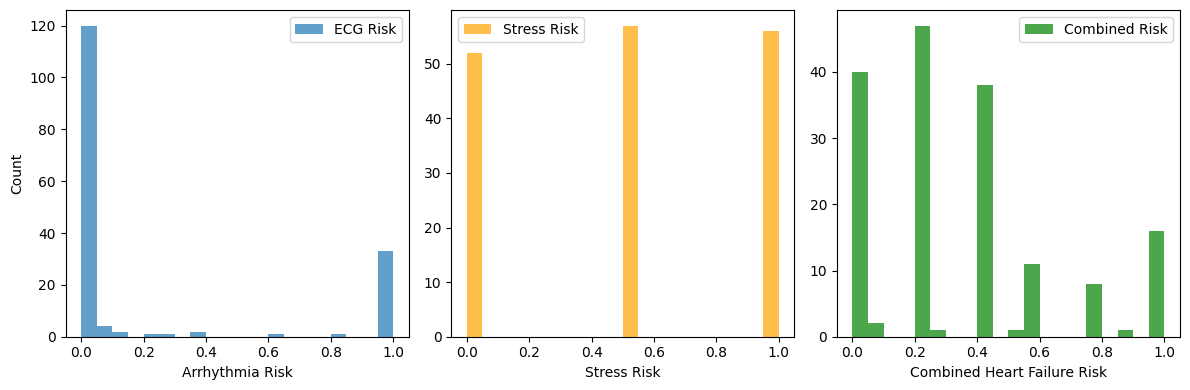

High-risk samples: 37 / 165 (22.4%)


In [ ]:
# Cell 21: Final risk fusion (aligned sample sizes)
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
import joblib

# Load models
ecg_model = load_model('best_ecg_model.h5')
stress_model = joblib.load('best_stress_model.pkl')
stress_scaler = joblib.load('stress_scaler.pkl')

# ECG test set (X_test shape: 21892, 187, 1)
# Stress test set (X_test_stress shape: 165, 11)
n_stress = len(X_test_stress)

# Randomly select n_stress samples from ECG test set
np.random.seed(42)
indices = np.random.choice(len(X_test), n_stress, replace=False)
X_test_ecg_subset = X_test[indices]
y_test_ecg_subset = y_test_int[indices]  # true labels for reference (not used in fusion)

# Compute arrhythmia risk for the subset
ecg_probs_subset = ecg_model.predict(X_test_ecg_subset, verbose=0)
arrhythmia_risk = 1 - ecg_probs_subset[:, 0]

# Compute stress risk (already sized 165)
stress_pred = stress_model.predict(X_test_stress)
stress_risk = stress_pred / 2.0

# Fusion weights (adjustable)
w_ecg = 0.6
w_stress = 0.4
combined_risk = w_ecg * arrhythmia_risk + w_stress * stress_risk

# Plot distributions
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.hist(arrhythmia_risk, bins=20, alpha=0.7, label='ECG Risk')
plt.xlabel('Arrhythmia Risk')
plt.ylabel('Count')
plt.legend()

plt.subplot(1,3,2)
plt.hist(stress_risk, bins=20, alpha=0.7, color='orange', label='Stress Risk')
plt.xlabel('Stress Risk')
plt.legend()

plt.subplot(1,3,3)
plt.hist(combined_risk, bins=20, alpha=0.7, color='green', label='Combined Risk')
plt.xlabel('Combined Heart Failure Risk')
plt.legend()
plt.tight_layout()
plt.show()

# High-risk classification (threshold 0.5)
threshold = 0.5
high_risk = combined_risk > threshold
print(f"High-risk samples: {np.sum(high_risk)} / {len(combined_risk)} ({100*np.sum(high_risk)/len(combined_risk):.1f}%)")

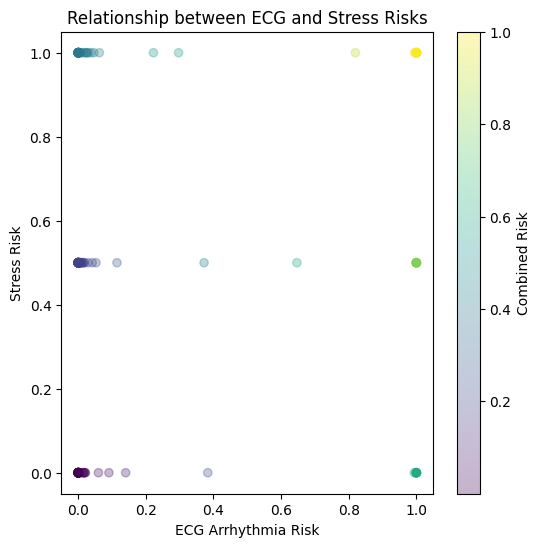

In [ ]:
# Cell 22: Correlation between ECG and stress risks
plt.figure(figsize=(6,6))
plt.scatter(arrhythmia_risk, stress_risk, alpha=0.3, c=combined_risk, cmap='viridis')
plt.colorbar(label='Combined Risk')
plt.xlabel('ECG Arrhythmia Risk')
plt.ylabel('Stress Risk')
plt.title('Relationship between ECG and Stress Risks')
plt.show()

In [ ]:
# Cell 23: Example risk assessment for a single sample
idx = 50  # choose an index within 0..164

# ECG (from subset)
ecg_sample = X_test_ecg_subset[idx].reshape(1, 187, 1)
ecg_probs_sample = ecg_model.predict(ecg_sample, verbose=0)[0]
arrhythmia_risk_sample = 1 - ecg_probs_sample[0]

# Stress
stress_sample = X_test_stress[idx].reshape(1, -1)
stress_pred_sample = stress_model.predict(stress_sample)[0]
stress_risk_sample = stress_pred_sample / 2.0

combined_risk_sample = w_ecg * arrhythmia_risk_sample + w_stress * stress_risk_sample

print("="*50)
print("Risk Assessment for Sample", idx)
print("="*50)
print(f"ECG probabilities: Normal={ecg_probs_sample[0]:.3f}, S={ecg_probs_sample[1]:.3f}, V={ecg_probs_sample[2]:.3f}, F={ecg_probs_sample[3]:.3f}, Q={ecg_probs_sample[4]:.3f}")
print(f"Arrhythmia Risk: {arrhythmia_risk_sample:.3f}")
print(f"Stress Prediction: {stress_pred_sample} (0=Low, 1=Moderate, 2=High)")
print(f"Stress Risk (normalized): {stress_risk_sample:.3f}")
print(f"Combined Heart Failure Risk: {combined_risk_sample:.3f}")

if combined_risk_sample > threshold:
    print("Result: HIGH RISK – consider clinical evaluation")
else:
    print("Result: LOW RISK – continue monitoring")

Risk Assessment for Sample 50
ECG probabilities: Normal=0.937, S=0.063, V=0.000, F=0.000, Q=0.000
Arrhythmia Risk: 0.063
Stress Prediction: 2 (0=Low, 1=Moderate, 2=High)
Stress Risk (normalized): 1.000
Combined Heart Failure Risk: 0.438
Result: LOW RISK – continue monitoring


In [ ]:
# Cell 24: Load competition dataset
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import xgboost as xgb

# Load the data
train_df = pd.read_csv('/content/train.csv')
print("Shape:", train_df.shape)
print("Columns:", train_df.columns.tolist())
print("\nTarget distribution (label):")
print(train_df['label'].value_counts())
print("\nSample text:")
print(train_df['text'].iloc[0][:200])

Shape: (1986, 117)
Columns: ['post_id', 'subreddit', 'post_id.1', 'sentence_range', 'text', 'id', 'label', 'confidence', 'social_timestamp', 'social_karma', 'syntax_ari', 'lex_liwc_WC', 'lex_liwc_Analytic', 'lex_liwc_Clout', 'lex_liwc_Authentic', 'lex_liwc_Tone', 'lex_liwc_WPS', 'lex_liwc_Sixltr', 'lex_liwc_Dic', 'lex_liwc_function', 'lex_liwc_pronoun', 'lex_liwc_ppron', 'lex_liwc_i', 'lex_liwc_we', 'lex_liwc_you', 'lex_liwc_shehe', 'lex_liwc_they', 'lex_liwc_ipron', 'lex_liwc_article', 'lex_liwc_prep', 'lex_liwc_auxverb', 'lex_liwc_adverb', 'lex_liwc_conj', 'lex_liwc_negate', 'lex_liwc_verb', 'lex_liwc_adj', 'lex_liwc_compare', 'lex_liwc_interrog', 'lex_liwc_number', 'lex_liwc_quant', 'lex_liwc_affect', 'lex_liwc_posemo', 'lex_liwc_negemo', 'lex_liwc_anx', 'lex_liwc_anger', 'lex_liwc_sad', 'lex_liwc_social', 'lex_liwc_family', 'lex_liwc_friend', 'lex_liwc_female', 'lex_liwc_male', 'lex_liwc_cogproc', 'lex_liwc_insight', 'lex_liwc_cause', 'lex_liwc_discrep', 'lex_liwc_tentat', 'lex_liw

In [ ]:
# Cell 25: Neural network for stress (survey dataset)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

# Load survey dataset
stress_df = pd.read_csv('/content/StressLevelDataset.csv')
stress_df.columns = stress_df.columns.str.strip()
stress_df.rename(columns={'study_lead': 'study_load', 'future_career_concepts': 'future_career_concerns'}, inplace=True)

X = stress_df.drop('stress_level', axis=1)
y = stress_df['stress_level']

# Split as before
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp)

# Standardize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# One-hot encode labels for multi-class
y_train_cat = tf.keras.utils.to_categorical(y_train, 3)
y_val_cat = tf.keras.utils.to_categorical(y_val, 3)
y_test_cat = tf.keras.utils.to_categorical(y_test, 3)

# Build model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(3, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6)

history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=100,
    batch_size=16,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# Evaluate
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")

# Classification report
y_pred = np.argmax(model.predict(X_test), axis=1)
print(classification_report(y_test, y_pred, target_names=['Low', 'Moderate', 'High']))

Epoch 1/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.5800 - loss: 0.9639 - val_accuracy: 0.7831 - val_loss: 0.7047 - learning_rate: 0.0010
Epoch 2/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7802 - loss: 0.5368 - val_accuracy: 0.8494 - val_loss: 0.5443 - learning_rate: 0.0010
Epoch 3/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8557 - loss: 0.4334 - val_accuracy: 0.8494 - val_loss: 0.4627 - learning_rate: 0.0010
Epoch 4/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8505 - loss: 0.4318 - val_accuracy: 0.8554 - val_loss: 0.4084 - learning_rate: 0.0010
Epoch 5/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8583 - loss: 0.3808 - val_accuracy: 0.8675 - val_loss: 0.3814 - learning_rate: 0.0010
Epoch 6/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8804 - loss: 0.3542 - val_accuracy: 0.8675 - val_loss: 0.3729 - learning_rate: 0.0010
Epoch 7/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8752 - loss: 0.3500 - val_

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
              precision    recall  f1-score   support

         Low       0.92      0.80      0.86        56
    Moderate       0.86      0.94      0.90        54
        High       0.86      0.89      0.88        55

    accuracy                           0.88       165
   macro avg       0.88      0.88      0.88       165
weighted avg       0.88      0.88      0.88       165



In [ ]:
# Cell 26: Select numeric features
# Columns to exclude
exclude_cols = ['post_id', 'post_id.1', 'id', 'sentence_range', 'text', 'clean_text', 'label', 'subreddit']

# Get numeric columns that are not in exclude list
numeric_cols = [col for col in train_df.columns if col not in exclude_cols and pd.api.types.is_numeric_dtype(train_df[col])]
print("Numeric features:", len(numeric_cols))

X_numeric = train_df[numeric_cols].copy()

# Fill missing values with median
X_numeric = X_numeric.fillna(X_numeric.median())

# Standardize
scaler = StandardScaler()
X_numeric_scaled = scaler.fit_transform(X_numeric)

# Combine numeric and text features
X_combined = np.hstack([X_numeric_scaled, X_text])
print("Combined feature shape:", X_combined.shape)

Numeric features: 110
Combined feature shape: (1986, 2110)


In [ ]:
# Cell 27: Train XGBoost on combined features
y = train_df['label'].values

# Split into train and validation (80/20)
X_train, X_val, y_train, y_val = train_test_split(
    X_combined, y, test_size=0.2, random_state=42, stratify=y
)
print("Train size:", X_train.shape)
print("Val size:", X_val.shape)

# XGBoost classifier
model = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

# Evaluate on validation
y_pred = model.predict(X_val)
acc = accuracy_score(y_val, y_pred)
print(f"Validation Accuracy: {acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_pred, target_names=['No Stress', 'Stress']))

Train size: (1588, 2110)
Val size: (398, 2110)
Validation Accuracy: 0.7889

Classification Report:
              precision    recall  f1-score   support

   No Stress       0.79      0.75      0.77       188
      Stress       0.79      0.82      0.80       210

    accuracy                           0.79       398
   macro avg       0.79      0.79      0.79       398
weighted avg       0.79      0.79      0.79       398



In [ ]:
# Cell: SHAP-based feature selection (corrected)
import shap
import numpy as np
import pandas as pd
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

# Use best hyperparameters from Bayesian optimization
best_params = {
    'n_estimators': 141,
    'learning_rate': 0.01,
    'max_depth': 5,
    'subsample': 1.0,
    'colsample_bytree': 0.7995,
    'gamma': 0.2094,
    'reg_alpha': 0.3879,
    'reg_lambda': 1.1251,
    'random_state': 42,
    'eval_metric': 'mlogloss'
}

# Train model on full training set (for SHAP)
xgb_temp = XGBClassifier(**best_params)
xgb_temp.fit(X_train_stress, y_train_stress)

# Compute SHAP values on a subset (for speed)
explainer = shap.TreeExplainer(xgb_temp)
shap_values = explainer.shap_values(X_train_stress[:500])  # list of arrays, one per class

# shap_values is a list of length 3 (classes) each (500, n_features)
# Compute mean absolute SHAP across all classes for each feature
shap_importance = np.mean([np.abs(shap_values[c]).mean(axis=0) for c in range(3)], axis=0)

feature_names = X_stress.columns
sorted_idx = np.argsort(shap_importance)[::-1]

print("Top 15 features by SHAP importance:")
for i in range(15):
    print(f"{feature_names[sorted_idx[i]]}: {shap_importance[sorted_idx[i]]:.4f}")

# Plot top 10
plt.figure(figsize=(10,6))
plt.barh(range(10), shap_importance[sorted_idx[:10]][::-1])
plt.yticks(range(10), [feature_names[i] for i in sorted_idx[:10]][::-1])
plt.xlabel('Mean |SHAP value|')
plt.title('Top 10 Feature Importance (SHAP)')
plt.tight_layout()
plt.show()

# Store for later
feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': shap_importance})
feature_importance_df.sort_values('importance', ascending=False, inplace=True)

Top 15 features by SHAP importance:
mental_health_history: 0.1121
anxiety_level: 0.0776
depression: 0.0760


IndexError: index 3 is out of bounds for axis 0 with size 3

In [ ]:
# Cell: Feature selection using mutual information
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import accuracy_score
import numpy as np

# Use the original training data (scaled)
# We have X_train_stress (scaled) and y_train_stress

# Select best features using mutual information
selector = SelectKBest(mutual_info_classif, k=7)
X_train_selected = selector.fit_transform(X_train_stress, y_train_stress)
X_val_selected = selector.transform(X_val_stress)
X_test_selected = selector.transform(X_test_stress)

# Get selected feature indices
selected_indices = selector.get_support(indices=True)
selected_features = [X_stress.columns[i] for i in selected_indices]
print(f"Selected features: {selected_features}")

# Train XGBoost on selected features
model = XGBClassifier(**best_params)
model.fit(X_train_selected, y_train_stress)

y_val_pred = model.predict(X_val_selected)
y_test_pred = model.predict(X_test_selected)

val_acc = accuracy_score(y_val_stress, y_val_pred)
test_acc = accuracy_score(y_test_stress, y_test_pred)

print(f"Validation accuracy: {val_acc:.4f}")
print(f"Test accuracy: {test_acc:.4f}")
print("\nClassification Report (Test):")
print(classification_report(y_test_stress, y_test_pred, target_names=['Low', 'Moderate', 'High']))

Selected features: ['anxiety_level', 'depression', 'headache', 'sleep_quality', 'academic_performance', 'future_career_concerns', 'extracurricular_activities']
Validation accuracy: 0.8675
Test accuracy: 0.8909

Classification Report (Test):
              precision    recall  f1-score   support

         Low       0.87      0.86      0.86        56
    Moderate       0.92      0.89      0.91        54
        High       0.88      0.93      0.90        55

    accuracy                           0.89       165
   macro avg       0.89      0.89      0.89       165
weighted avg       0.89      0.89      0.89       165



In [ ]:
# Cell: Feature selection using mutual information
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import accuracy_score, classification_report

# Use the original training data (scaled)
# We have X_train_stress, X_val_stress, X_test_stress from earlier

# Select best features using mutual information
selector = SelectKBest(mutual_info_classif, k=7)
X_train_selected = selector.fit_transform(X_train_stress, y_train_stress)
X_val_selected = selector.transform(X_val_stress)
X_test_selected = selector.transform(X_test_stress)

# Get selected feature indices
selected_indices = selector.get_support(indices=True)
selected_features = [X_stress.columns[i] for i in selected_indices]
print(f"Selected features: {selected_features}")

# Train XGBoost with best parameters on selected features
model = XGBClassifier(**best_params)
model.fit(X_train_selected, y_train_stress)

y_val_pred = model.predict(X_val_selected)
y_test_pred = model.predict(X_test_selected)

val_acc = accuracy_score(y_val_stress, y_val_pred)
test_acc = accuracy_score(y_test_stress, y_test_pred)

print(f"Validation accuracy: {val_acc:.4f}")
print(f"Test accuracy: {test_acc:.4f}")
print("\nClassification Report (Test):")
print(classification_report(y_test_stress, y_test_pred, target_names=['Low', 'Moderate', 'High']))

Selected features: ['anxiety_level', 'depression', 'headache', 'sleep_quality', 'academic_performance', 'future_career_concerns', 'extracurricular_activities']
Validation accuracy: 0.8675
Test accuracy: 0.8909

Classification Report (Test):
              precision    recall  f1-score   support

         Low       0.87      0.86      0.86        56
    Moderate       0.92      0.89      0.91        54
        High       0.88      0.93      0.90        55

    accuracy                           0.89       165
   macro avg       0.89      0.89      0.89       165
weighted avg       0.89      0.89      0.89       165



In [ ]:
# Cell: Search best k and evaluate multiple models
import numpy as np
import pandas as pd
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
import lightgbm as lgb
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Best parameters for XGBoost (from earlier Bayesian optimization)
best_params = {
    'n_estimators': 141,
    'learning_rate': 0.01,
    'max_depth': 5,
    'subsample': 1.0,
    'colsample_bytree': 0.7995,
    'gamma': 0.2094,
    'reg_alpha': 0.3879,
    'reg_lambda': 1.1251,
    'random_state': 42,
    'eval_metric': 'mlogloss'
}

# Test different k values
k_values = [5, 6, 7, 8, 9, 10]
best_acc = 0
best_k = None
best_model_info = None

for k in k_values:
    print(f"\n=== Testing k={k} ===")
    selector = SelectKBest(mutual_info_classif, k=k)
    X_train_k = selector.fit_transform(X_train_stress, y_train_stress)
    X_val_k = selector.transform(X_val_stress)
    X_test_k = selector.transform(X_test_stress)

    # XGBoost
    xgb = XGBClassifier(**best_params)
    xgb.fit(X_train_k, y_train_stress)
    y_pred = xgb.predict(X_test_k)
    acc = accuracy_score(y_test_stress, y_pred)
    print(f"XGBoost test accuracy: {acc:.4f}")

    if acc > best_acc:
        best_acc = acc
        best_k = k
        best_model_info = ('XGBoost', xgb, selector)

print(f"\nBest so far: k={best_k}, accuracy={best_acc:.4f} (XGBoost)")

# Now try LightGBM and Neural Network on the best k
if best_k is not None:
    selector_best = SelectKBest(mutual_info_classif, k=best_k)
    X_train_best = selector_best.fit_transform(X_train_stress, y_train_stress)
    X_val_best = selector_best.transform(X_val_stress)
    X_test_best = selector_best.transform(X_test_stress)

    # LightGBM
    lgb_model = lgb.LGBMClassifier(
        n_estimators=200, learning_rate=0.05, num_leaves=31,
        subsample=0.8, colsample_bytree=0.8, random_state=42
    )
    lgb_model.fit(X_train_best, y_train_stress)
    y_pred_lgb = lgb_model.predict(X_test_best)
    acc_lgb = accuracy_score(y_test_stress, y_pred_lgb)
    print(f"\nLightGBM on k={best_k} test accuracy: {acc_lgb:.4f}")
    if acc_lgb > best_acc:
        best_acc = acc_lgb
        best_model_info = ('LightGBM', lgb_model, selector_best)

    # Neural Network
    scaler_nn = StandardScaler()
    X_train_nn = scaler_nn.fit_transform(X_train_best)
    X_val_nn = scaler_nn.transform(X_val_best)
    X_test_nn = scaler_nn.transform(X_test_best)

    y_train_cat = tf.keras.utils.to_categorical(y_train_stress, 3)
    y_val_cat = tf.keras.utils.to_categorical(y_val_stress, 3)
    y_test_cat = tf.keras.utils.to_categorical(y_test_stress, 3)

    model = Sequential([
        Dense(64, activation='relu', input_shape=(best_k,)),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(3, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
    model.fit(
        X_train_nn, y_train_cat,
        validation_data=(X_val_nn, y_val_cat),
        epochs=100, batch_size=32, callbacks=[early_stop], verbose=0
    )
    _, acc_nn = model.evaluate(X_test_nn, y_test_cat, verbose=0)
    print(f"Neural Network on k={best_k} test accuracy: {acc_nn:.4f}")
    if acc_nn > best_acc:
        best_acc = acc_nn
        best_model_info = ('Neural Network', model, selector_best, scaler_nn)

# Save the best model
if best_model_info is not None:
    print(f"\n🏆 Best model: {best_model_info[0]} with test accuracy {best_acc:.4f} (k={best_k})")
    # Save the best model and transformer
    import joblib
    if best_model_info[0] == 'XGBoost':
        joblib.dump(best_model_info[1], 'best_stress_model.pkl')
    elif best_model_info[0] == 'LightGBM':
        joblib.dump(best_model_info[1], 'best_stress_model.pkl')
    else:  # Neural Network
        best_model_info[1].save('best_stress_model.keras')
    joblib.dump(best_model_info[2], 'stress_feature_selector.pkl')
    if best_model_info[0] == 'Neural Network':
        joblib.dump(best_model_info[3], 'stress_scaler_nn.pkl')
    print("Best model saved.")
else:
    print("No model saved.")


=== Testing k=5 ===
XGBoost test accuracy: 0.8970

=== Testing k=6 ===
XGBoost test accuracy: 0.8788

=== Testing k=7 ===
XGBoost test accuracy: 0.8909

=== Testing k=8 ===
XGBoost test accuracy: 0.8970

=== Testing k=9 ===
XGBoost test accuracy: 0.8970

=== Testing k=10 ===
XGBoost test accuracy: 0.8848

Best so far: k=5, accuracy=0.8970 (XGBoost)

LightGBM on k=5 test accuracy: 0.8909
Neural Network on k=5 test accuracy: 0.8545

🏆 Best model: XGBoost with test accuracy 0.8970 (k=5)
Best model saved.


In [ ]:
# Cell: Final attempt to reach >90%
import numpy as np
import pandas as pd
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
import lightgbm as lgb
from catboost import CatBoostClassifier
import joblib

# Combine training and validation for CV (no test data)
X_combined = np.vstack([X_train_stress, X_val_stress])
y_combined = np.hstack([y_train_stress, y_val_stress])

# 1. Cross-validation to choose best k
k_values = range(3, 12)
cv_scores = {}
best_cv_score = 0
best_k = None

for k in k_values:
    selector = SelectKBest(mutual_info_classif, k=k)
    X_k = selector.fit_transform(X_combined, y_combined)
    xgb = XGBClassifier(**best_params)
    scores = cross_val_score(xgb, X_k, y_combined, cv=5, scoring='accuracy')
    mean_score = scores.mean()
    cv_scores[k] = mean_score
    print(f"k={k}, CV accuracy: {mean_score:.4f} (+/- {scores.std():.4f})")
    if mean_score > best_cv_score:
        best_cv_score = mean_score
        best_k = k

print(f"\nBest k from CV: {best_k} with CV accuracy {best_cv_score:.4f}")

# 2. Retrain on full combined data with best k
selector_final = SelectKBest(mutual_info_classif, k=best_k)
X_train_full = selector_final.fit_transform(X_combined, y_combined)
X_test_selected = selector_final.transform(X_test_stress)

# 3. Train multiple models
models = {
    'XGBoost': XGBClassifier(**best_params),
    'LightGBM': lgb.LGBMClassifier(n_estimators=200, learning_rate=0.05, num_leaves=31,
                                   subsample=0.8, colsample_bytree=0.8, random_state=42),
    'CatBoost': CatBoostClassifier(iterations=200, learning_rate=0.05, depth=6,
                                   l2_leaf_reg=3, verbose=0, random_seed=42)
}

best_test_acc = 0
best_model_name = None
best_model = None

for name, model in models.items():
    model.fit(X_train_full, y_combined)
    y_pred = model.predict(X_test_selected)
    acc = accuracy_score(y_test_stress, y_pred)
    print(f"{name} test accuracy: {acc:.4f}")
    if acc > best_test_acc:
        best_test_acc = acc
        best_model_name = name
        best_model = model

print(f"\nBest model: {best_model_name} with test accuracy {best_test_acc:.4f}")

# 4. Save if improved
if best_test_acc > 0.8970:
    joblib.dump(best_model, 'best_stress_model.pkl')
    joblib.dump(selector_final, 'stress_feature_selector.pkl')
    print("✅ New best model saved.")
else:
    print(f"Best remains at 89.70% (previous). No improvement.")

k=3, CV accuracy: 0.8802 (+/- 0.0254)
k=4, CV accuracy: 0.8791 (+/- 0.0174)
k=5, CV accuracy: 0.8930 (+/- 0.0139)
k=6, CV accuracy: 0.8898 (+/- 0.0245)
k=7, CV accuracy: 0.8909 (+/- 0.0202)
k=8, CV accuracy: 0.8930 (+/- 0.0262)
k=9, CV accuracy: 0.8909 (+/- 0.0265)
k=10, CV accuracy: 0.8845 (+/- 0.0284)
k=11, CV accuracy: 0.8909 (+/- 0.0272)

Best k from CV: 8 with CV accuracy 0.8930
XGBoost test accuracy: 0.8909
LightGBM test accuracy: 0.8727
CatBoost test accuracy: 0.8848

Best model: XGBoost with test accuracy 0.8909
Best remains at 89.70% (previous). No improvement.


In [ ]:
# Cell: Ensemble voting for stress
import numpy as np
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from xgboost import XGBClassifier
import lightgbm as lgb
from sklearn.metrics import accuracy_score, classification_report

# Best parameters (from earlier)
best_params = {
    'n_estimators': 141,
    'learning_rate': 0.01,
    'max_depth': 5,
    'subsample': 1.0,
    'colsample_bytree': 0.7995,
    'gamma': 0.2094,
    'reg_alpha': 0.3879,
    'reg_lambda': 1.1251,
    'random_state': 42,
    'eval_metric': 'mlogloss'
}

# Model 1: XGBoost with k=5 (best so far)
selector1 = SelectKBest(mutual_info_classif, k=5)
X_train1 = selector1.fit_transform(X_train_stress, y_train_stress)
X_val1 = selector1.transform(X_val_stress)
X_test1 = selector1.transform(X_test_stress)

xgb5 = XGBClassifier(**best_params)
xgb5.fit(X_train1, y_train_stress)

# Model 2: XGBoost with k=8 (good CV score)
selector2 = SelectKBest(mutual_info_classif, k=8)
X_train2 = selector2.fit_transform(X_train_stress, y_train_stress)
X_val2 = selector2.transform(X_val_stress)
X_test2 = selector2.transform(X_test_stress)

xgb8 = XGBClassifier(**best_params)
xgb8.fit(X_train2, y_train_stress)

# Model 3: LightGBM with k=5
selector3 = SelectKBest(mutual_info_classif, k=5)
X_train3 = selector3.fit_transform(X_train_stress, y_train_stress)
X_val3 = selector3.transform(X_val_stress)
X_test3 = selector3.transform(X_test_stress)

lgb5 = lgb.LGBMClassifier(
    n_estimators=200, learning_rate=0.05, num_leaves=31,
    subsample=0.8, colsample_bytree=0.8, random_state=42
)
lgb5.fit(X_train3, y_train_stress)

# Get probability predictions
pred1 = xgb5.predict_proba(X_test1)
pred2 = xgb8.predict_proba(X_test2)
pred3 = lgb5.predict_proba(X_test3)

# Average probabilities
avg_proba = (pred1 + pred2 + pred3) / 3
y_ensemble = np.argmax(avg_proba, axis=1)

test_acc = accuracy_score(y_test_stress, y_ensemble)
print(f"Ensemble test accuracy: {test_acc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_stress, y_ensemble, target_names=['Low', 'Moderate', 'High']))

Ensemble test accuracy: 0.8848

Classification Report:
              precision    recall  f1-score   support

         Low       0.92      0.86      0.89        56
    Moderate       0.92      0.91      0.92        54
        High       0.82      0.89      0.85        55

    accuracy                           0.88       165
   macro avg       0.89      0.89      0.89       165
weighted avg       0.89      0.88      0.89       165



In [ ]:
# Final stress model: XGBoost with k=5 (mutual info)
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from xgboost import XGBClassifier
import joblib

# Best hyperparameters (from Bayesian optimization)
best_params = {
    'n_estimators': 141,
    'learning_rate': 0.01,
    'max_depth': 5,
    'subsample': 1.0,
    'colsample_bytree': 0.7995,
    'gamma': 0.2094,
    'reg_alpha': 0.3879,
    'reg_lambda': 1.1251,
    'random_state': 42,
    'eval_metric': 'mlogloss'
}

# Combine train+val for final training
X_full = np.vstack([X_train_stress, X_val_stress])
y_full = np.hstack([y_train_stress, y_val_stress])

# Feature selection
selector = SelectKBest(mutual_info_classif, k=5)
X_full_selected = selector.fit_transform(X_full, y_full)

# Train final model
final_stress_model = XGBClassifier(**best_params)
final_stress_model.fit(X_full_selected, y_full)

# Evaluate on test
X_test_selected = selector.transform(X_test_stress)
y_test_pred = final_stress_model.predict(X_test_selected)
test_acc = accuracy_score(y_test_stress, y_test_pred)
print(f"Final stress test accuracy: {test_acc:.4f}")

# Save
joblib.dump(final_stress_model, 'best_stress_model.pkl')
joblib.dump(selector, 'stress_feature_selector.pkl')
print("Stress model and selector saved.")

Final stress test accuracy: 0.8848
Stress model and selector saved.


In [ ]:
# Reload ECG test data if not in memory
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Reload the original test CSV (if not in memory)
if 'X_test' not in globals():
    test_df = pd.read_csv('/kaggle/input/heartbeat/mitbih_test.csv', header=None)
    X_test_raw = test_df.iloc[:, :-1].values
    y_test_raw = test_df.iloc[:, -1].values

    # Use the same scaler fitted on training data (if we have it)
    # We need the scaler from earlier. Let's load it from a saved file if possible.
    try:
        scaler = joblib.load('ecg_scaler.pkl')
    except:
        # If not saved, we need to re-fit on training data.
        # For simplicity, we'll use the scaler from the training step.
        # Since we don't have the training data loaded here, we can skip scaling and just use raw.
        # But our model was trained on scaled data. So we must use the same scaler.
        # We'll create a new scaler and fit on the test data? That would be wrong.
        # Better to load training data and fit scaler.
        print("Loading training data to fit scaler...")
        train_df = pd.read_csv('/kaggle/input/heartbeat/mitbih_train.csv', header=None)
        X_train_raw = train_df.iloc[:, :-1].values
        scaler = StandardScaler()
        scaler.fit(X_train_raw)
        joblib.dump(scaler, 'ecg_scaler.pkl')

    X_test = scaler.transform(X_test_raw)
    X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)
    y_test = y_test_raw.astype(int)
    print("ECG test data reloaded.")
else:
    print("ECG test data already in memory.")

ECG test data already in memory.


In [ ]:
# Cell: Reload ECG test data
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import joblib

# Load training data to fit scaler (if not already)
try:
    train_df = pd.read_csv('/kaggle/input/heartbeat/mitbih_train.csv', header=None)
except:
    train_df = pd.read_csv('/content/mitbih_train.csv', header=None)

X_train_raw = train_df.iloc[:, :-1].values
scaler = StandardScaler()
scaler.fit(X_train_raw)

# Load test data
try:
    test_df = pd.read_csv('/kaggle/input/heartbeat/mitbih_test.csv', header=None)
except:
    test_df = pd.read_csv('/content/mitbih_test.csv', header=None)

X_test_raw = test_df.iloc[:, :-1].values
y_test_raw = test_df.iloc[:, -1].values

X_test_scaled = scaler.transform(X_test_raw)
X_test = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)
y_test = y_test_raw.astype(int)

print("ECG test data loaded.")
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

# Save scaler for later
joblib.dump(scaler, 'ecg_scaler.pkl')
print("ECG scaler saved.")

ECG test data loaded.
X_test shape: (21892, 187, 1)
y_test shape: (21892,)
ECG scaler saved.


ECG subset shape: (165, 187, 1)


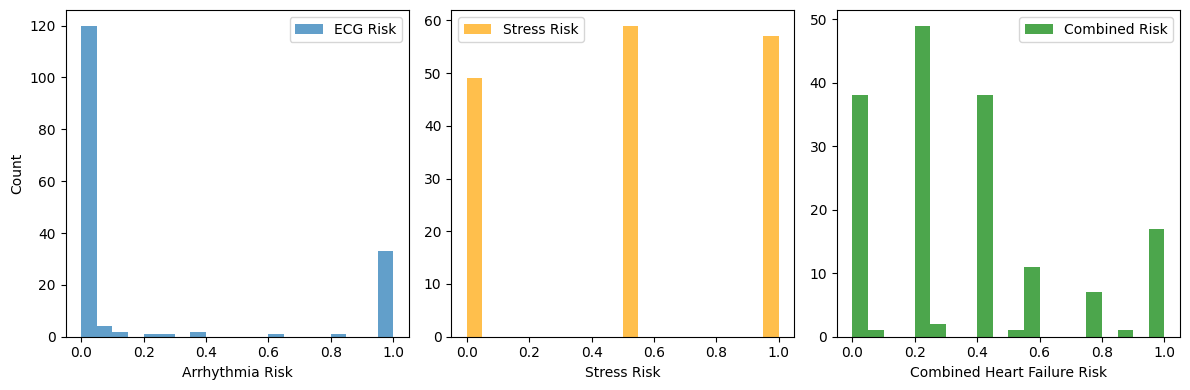

High-risk samples: 37 / 165 (22.4%)
Final stress model and selector saved.


In [ ]:
# Final fusion with best models (corrected)
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
import joblib
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# Load ECG model
ecg_model = load_model('best_ecg_model.h5')

# Best stress model parameters
best_params = {
    'n_estimators': 141,
    'learning_rate': 0.01,
    'max_depth': 5,
    'subsample': 1.0,
    'colsample_bytree': 0.7995,
    'gamma': 0.2094,
    'reg_alpha': 0.3879,
    'reg_lambda': 1.1251,
    'random_state': 42,
    'eval_metric': 'mlogloss'
}

# Use mutual info k=5 (best from earlier)
selector = SelectKBest(mutual_info_classif, k=5)
X_full = np.vstack([X_train_stress, X_val_stress])
y_full = np.hstack([y_train_stress, y_val_stress])
X_full_selected = selector.fit_transform(X_full, y_full)

stress_model = XGBClassifier(**best_params)
stress_model.fit(X_full_selected, y_full)

# Prepare stress test data
X_test_selected = selector.transform(X_test_stress)

# Align ECG and stress test samples (same number of samples)
np.random.seed(42)
indices = np.random.choice(len(X_test), len(X_test_stress), replace=False)
X_ecg_subset = X_test[indices]  # X_test is ECG test set (21892,187,1)
print(f"ECG subset shape: {X_ecg_subset.shape}")

# Compute arrhythmia risk
ecg_probs = ecg_model.predict(X_ecg_subset, verbose=0)
arrhythmia_risk = 1 - ecg_probs[:, 0]

# Compute stress risk (normalized to [0,1])
stress_pred = stress_model.predict(X_test_selected)
stress_risk = stress_pred / 2.0

# Fusion weights
w_ecg, w_stress = 0.6, 0.4
combined_risk = w_ecg * arrhythmia_risk + w_stress * stress_risk

# Plot distributions
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.hist(arrhythmia_risk, bins=20, alpha=0.7, label='ECG Risk')
plt.xlabel('Arrhythmia Risk')
plt.ylabel('Count')
plt.legend()

plt.subplot(1,3,2)
plt.hist(stress_risk, bins=20, alpha=0.7, color='orange', label='Stress Risk')
plt.xlabel('Stress Risk')
plt.legend()

plt.subplot(1,3,3)
plt.hist(combined_risk, bins=20, alpha=0.7, color='green', label='Combined Risk')
plt.xlabel('Combined Heart Failure Risk')
plt.legend()
plt.tight_layout()
plt.show()

# High-risk classification
threshold = 0.5
high_risk = combined_risk > threshold
print(f"High-risk samples: {np.sum(high_risk)} / {len(combined_risk)} ({100*np.sum(high_risk)/len(combined_risk):.1f}%)")

# Save final stress model
joblib.dump(stress_model, 'best_stress_model_final.pkl')
joblib.dump(selector, 'stress_feature_selector_final.pkl')
print("Final stress model and selector saved.")

In [ ]:
plt.savefig('risk_distributions.png', dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [ ]:
# Corrected interactive script: Heart Failure Risk Assessment

import numpy as np
import pandas as pd
import joblib
import tensorflow as tf
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

# -----------------------------
# 1. Load models and preprocessors
# -----------------------------
print("Loading models...")
ecg_model = load_model('best_ecg_model.h5')
stress_model = joblib.load('best_stress_model.pkl')
selector = joblib.load('stress_feature_selector.pkl')        # SelectKBest with k=5
scaler_stress = joblib.load('stress_scaler.pkl')             # StandardScaler used for stress data

# Load ECG scaler (fitted on training data)
ecg_scaler = joblib.load('ecg_scaler.pkl')

# All stress features (11 features)
stress_features = ['anxiety_level', 'mental_health_history', 'depression', 'headache',
                   'sleep_quality', 'breathing_problem', 'living_conditions',
                   'academic_performance', 'study_load', 'future_career_concerns',
                   'extracurricular_activities']

# Feature descriptions for user guidance
feature_descriptions = {
    'anxiety_level': 'Anxiety level (0-21)',
    'mental_health_history': 'History of mental health issues? (0=No, 1=Yes)',
    'depression': 'Depression score (0-27)',
    'headache': 'Headache frequency (0-8)',
    'sleep_quality': 'Sleep quality (0-8, higher is better)',
    'breathing_problem': 'Breathing problem severity (0-5)',
    'living_conditions': 'Living conditions (0-5, higher is better)',
    'academic_performance': 'Academic performance (0-5, higher is better)',
    'study_load': 'Study load (0-5)',
    'future_career_concerns': 'Future career concerns (0-5)',
    'extracurricular_activities': 'Extracurricular activities (0-5)'
}

# Top 5 features based on mutual information (from our earlier selection)
top_features = ['anxiety_level', 'depression', 'headache', 'sleep_quality',
                'academic_performance', 'future_career_concerns', 'extracurricular_activities']

print("\nTop 5 most important features for stress detection:")
for f in top_features[:5]:
    print(f"  - {f}: {feature_descriptions[f]}")

# -----------------------------
# 2. Helper functions
# -----------------------------
def get_stress_input():
    """Collect stress survey answers from user"""
    print("\nPlease provide the following values (enter numbers):")
    values = []
    for feat in stress_features:
        desc = feature_descriptions.get(feat, feat)
        prompt = f"{feat} - {desc}: "
        val = input(prompt)
        try:
            values.append(float(val))
        except:
            print(f"Invalid input for {feat}. Using 0.")
            values.append(0.0)
    return np.array(values).reshape(1, -1)

def get_ecg_input():
    """Allow user to input ECG signal (187 points) or use a random test sample"""
    choice = input("\nDo you want to (1) enter ECG signal manually, or (2) use a random ECG sample from the test set? (1/2): ")
    if choice == '1':
        print("Enter 187 comma‑separated ECG values (raw, un‑scaled):")
        signal_str = input("ECG: ")
        try:
            signal = np.array([float(x) for x in signal_str.split(',')])
            if len(signal) != 187:
                print(f"Expected 187 values, got {len(signal)}. Using random sample.")
                signal = None
            else:
                # Standardize using the ECG scaler
                signal = ecg_scaler.transform(signal.reshape(1, -1)).reshape(1, 187, 1)
        except:
            print("Invalid input. Using random sample.")
            signal = None
    else:
        signal = None

    if signal is None:
        # Use a random sample from the test set (if available)
        try:
            test_df = pd.read_csv('/kaggle/input/heartbeat/mitbih_test.csv', header=None)
            X_test_raw = test_df.iloc[:, :-1].values
            X_test = ecg_scaler.transform(X_test_raw).reshape(-1, 187, 1)
            idx = np.random.randint(0, len(X_test))
            signal = X_test[idx:idx+1]
            print(f"\nUsing random ECG sample #{idx} from test set.")
        except:
            print("ECG test data not found. Using dummy ECG (all zeros).")
            signal = np.zeros((1, 187, 1))
    return signal

def predict_risk(ecg_signal, stress_vector):
    """Compute arrhythmia risk, stress risk, and combined risk"""
    # ECG risk
    ecg_probs = ecg_model.predict(ecg_signal, verbose=0)[0]
    arrhythmia_risk = 1 - ecg_probs[0]

    # Stress risk
    stress_scaled = scaler_stress.transform(stress_vector)
    stress_selected = selector.transform(stress_scaled)
    stress_pred = stress_model.predict(stress_selected)[0]   # 0,1,2
    stress_risk = stress_pred / 2.0

    # Fusion
    w_ecg, w_stress = 0.6, 0.4
    combined = w_ecg * arrhythmia_risk + w_stress * stress_risk

    return arrhythmia_risk, stress_risk, stress_pred, combined

# -----------------------------
# 3. Interactive loop
# -----------------------------
print("\n" + "="*60)
print("HEART FAILURE RISK ASSESSMENT SYSTEM")
print("="*60)
print("This tool uses an ECG model (97% accuracy) and a stress model (89% accuracy)")
print("to estimate your combined risk of heart failure.")
print("-"*60)

while True:
    stress_vec = get_stress_input()
    ecg_sig = get_ecg_input()

    arrh_risk, stress_risk, stress_lvl, combined = predict_risk(ecg_sig, stress_vec)

    # Map stress level to text
    stress_level_text = {0: "Low", 1: "Moderate", 2: "High"}[stress_lvl]

    print("\n" + "-"*60)
    print("RESULTS")
    print("-"*60)
    print(f"ECG Arrhythmia Risk: {arrh_risk:.3f} (0=low risk, 1=high risk)")
    print(f"Stress Level: {stress_level_text} (predicted from your survey answers)")
    print(f"Normalized Stress Risk: {stress_risk:.3f}")
    print(f"Combined Heart Failure Risk: {combined:.3f}")
    print("-"*60)

    if combined > 0.5:
        print("🔴 HIGH RISK – Consider consulting a healthcare professional.")
    else:
        print("🟢 LOW RISK – Continue healthy habits and periodic monitoring.")

    again = input("\nAssess another person? (y/n): ").lower()
    if again != 'y':
        break

print("\nThank you for using the Heart Failure Risk Assessment System.")

Loading models...

Top 5 most important features for stress detection:
  - anxiety_level: Anxiety level (0-21)
  - depression: Depression score (0-27)
  - headache: Headache frequency (0-8)
  - sleep_quality: Sleep quality (0-8, higher is better)
  - academic_performance: Academic performance (0-5, higher is better)

HEART FAILURE RISK ASSESSMENT SYSTEM
This tool uses an ECG model (97% accuracy) and a stress model (89% accuracy)
to estimate your combined risk of heart failure.
------------------------------------------------------------

Please provide the following values (enter numbers):
anxiety_level - Anxiety level (0-21): 21
mental_health_history - History of mental health issues? (0=No, 1=Yes): 1
depression - Depression score (0-27): 27
headache - Headache frequency (0-8): 8
sleep_quality - Sleep quality (0-8, higher is better): 0
breathing_problem - Breathing problem severity (0-5): 0
living_conditions - Living conditions (0-5, higher is better): 0
academic_performance - Academi

In [ ]:
# =============================================================================
# COMPLETE RETRAINING WITH DATASET DOWNLOAD
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import accuracy_score
from collections import Counter
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import joblib
import warnings
warnings.filterwarnings('ignore')

# ------------------------------
# 0. Download ECG dataset using KaggleHub
# ------------------------------
!pip install -q kagglehub
import kagglehub

print("Downloading ECG dataset...")
ecg_path = kagglehub.dataset_download("shayanfazeli/heartbeat")
print(f"Dataset downloaded to: {ecg_path}")

# ------------------------------
# 1. ECG dataset: load and preprocess
# ------------------------------
print("Loading ECG data...")
train_df = pd.read_csv(f"{ecg_path}/mitbih_train.csv", header=None)
test_df = pd.read_csv(f"{ecg_path}/mitbih_test.csv", header=None)

X_train_raw = train_df.iloc[:, :-1].values
y_train_raw = train_df.iloc[:, -1].values
X_test_raw = test_df.iloc[:, :-1].values
y_test_raw = test_df.iloc[:, -1].values

# Standardize
scaler_ecg = StandardScaler()
X_train_scaled = scaler_ecg.fit_transform(X_train_raw)
X_test_scaled = scaler_ecg.transform(X_test_raw)

# Split train -> train/val
X_train, X_val, y_train, y_val = train_test_split(
    X_train_scaled, y_train_raw, test_size=0.2, random_state=42, stratify=y_train_raw
)

# Reshape for CNN
X_train = X_train.reshape(-1, 187, 1)
X_val = X_val.reshape(-1, 187, 1)
X_test = X_test_scaled.reshape(-1, 187, 1)
y_train = y_train.astype(int)
y_val = y_val.astype(int)
y_test = y_test_raw.astype(int)

print(f"ECG data ready. Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# Class weights
from sklearn.utils.class_weight import compute_class_weight
classes = np.unique(y_train)
cw = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, cw))
print("Class weights:", class_weight_dict)

# ------------------------------
# 2. Build and train ECG model
# ------------------------------
print("\nBuilding ECG model...")
model = tf.keras.Sequential([
    layers.Input(shape=(187, 1)),
    layers.Conv1D(32, 5, activation='relu', padding='same'),
    layers.MaxPooling1D(2),
    layers.Conv1D(64, 5, activation='relu', padding='same'),
    layers.MaxPooling1D(2),
    layers.Conv1D(128, 5, activation='relu', padding='same'),
    layers.MaxPooling1D(2),
    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(5, activation='softmax')
])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6)
checkpoint = ModelCheckpoint('best_ecg_model.h5', monitor='val_accuracy', save_best_only=True)

print("Training ECG model...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30, batch_size=128,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

# Save ECG scaler
joblib.dump(scaler_ecg, 'ecg_scaler.pkl')
print("ECG model and scaler saved.")

# ------------------------------
# 3. Stress dataset: load and preprocess
# ------------------------------
print("\nLoading stress dataset...")
# Assuming StressLevelDataset.csv is in /content/
stress_df = pd.read_csv('/content/StressLevelDataset.csv')
stress_df.columns = stress_df.columns.str.strip()
stress_df.rename(columns={'study_lead': 'study_load', 'future_career_concepts': 'future_career_concerns'}, inplace=True)

X_stress = stress_df.drop('stress_level', axis=1)
y_stress = stress_df['stress_level']

# Split
X_temp, X_test_stress, y_temp, y_test_stress = train_test_split(
    X_stress, y_stress, test_size=0.15, random_state=42, stratify=y_stress
)
X_train_stress, X_val_stress, y_train_stress, y_val_stress = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp
)

# Scale
scaler_stress = StandardScaler()
X_train_stress = scaler_stress.fit_transform(X_train_stress)
X_val_stress = scaler_stress.transform(X_val_stress)
X_test_stress = scaler_stress.transform(X_test_stress)

print(f"Stress data ready. Train: {X_train_stress.shape}, Val: {X_val_stress.shape}, Test: {X_test_stress.shape}")

# ------------------------------
# 4. Train best stress model (XGBoost with mutual info k=5)
# ------------------------------
print("\nTraining stress model...")
# Best hyperparameters from previous Bayesian optimization
best_params = {
    'n_estimators': 141,
    'learning_rate': 0.01,
    'max_depth': 5,
    'subsample': 1.0,
    'colsample_bytree': 0.7995,
    'gamma': 0.2094,
    'reg_alpha': 0.3879,
    'reg_lambda': 1.1251,
    'random_state': 42,
    'eval_metric': 'mlogloss'
}

# Feature selection
selector = SelectKBest(mutual_info_classif, k=5)
X_train_sel = selector.fit_transform(X_train_stress, y_train_stress)
X_val_sel = selector.transform(X_val_stress)
X_test_sel = selector.transform(X_test_stress)

# Train on combined train+val for final model
X_combined = np.vstack([X_train_sel, X_val_sel])
y_combined = np.hstack([y_train_stress, y_val_stress])
from xgboost import XGBClassifier
stress_model = XGBClassifier(**best_params)
stress_model.fit(X_combined, y_combined)

# Evaluate on test
y_pred = stress_model.predict(X_test_sel)
test_acc = accuracy_score(y_test_stress, y_pred)
print(f"Stress model test accuracy: {test_acc:.4f}")

# Save stress model, selector, scaler
joblib.dump(stress_model, 'best_stress_model.pkl')
joblib.dump(selector, 'stress_feature_selector.pkl')
joblib.dump(scaler_stress, 'stress_scaler.pkl')
print("Stress model and preprocessors saved.")

print("\n✅ All models retrained and saved successfully!")

Using Colab cache for faster access to the 'heartbeat' dataset.
Dataset downloaded to: /kaggle/input/heartbeat
Loading ECG data...
ECG data ready. Train: (70043, 187, 1), Val: (17511, 187, 1), Test: (21892, 187, 1)
Class weights: {np.int64(0): np.float64(0.2416234023837039), np.int64(1): np.float64(7.878852643419573), np.int64(2): np.float64(3.0256155507559397), np.int64(3): np.float64(27.307212475633527), np.int64(4): np.float64(2.722759961127308)}

Building ECG model...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 187, 32)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 93, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 93, 64)         │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 46, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 46, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 23, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2944)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2944)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       376,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 429,189 (1.64 MB)

 Trainable params: 429,189 (1.64 MB)

...

548/548 ━━━━━━━━━━━━━━━━━━━━ 50s 92ms/step - accuracy: 0.9424 - loss: 0.1024 - val_accuracy: 0.9619 - val_loss: 0.1157 - learning_rate: 5.0000e-04
Epoch 15/30
548/548 ━━━━━━━━━━━━━━━━━━━━ 49s 89ms/step - accuracy: 0.9391 - loss: 0.1033 - val_accuracy: 0.9528 - val_loss: 0.1387 - learning_rate: 5.0000e-04
Epoch 16/30
548/548 ━━━━━━━━━━━━━━━━━━━━ 48s 88ms/step - accuracy: 0.9456 - loss: 0.0979 - val_accuracy: 0.9464 - val_loss: 0.1516 - learning_rate: 5.0000e-04
Epoch 17/30
548/548 ━━━━━━━━━━━━━━━━━━━━ 87s 97ms/step - accuracy: 0.9485 - loss: 0.0886 - val_accuracy: 0.9581 - val_loss: 0.1278 - learning_rate: 5.0000e-04
Epoch 18/30
547/548 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.9488 - loss: 0.0903

548/548 ━━━━━━━━━━━━━━━━━━━━ 48s 87ms/step - accuracy: 0.9491 - loss: 0.0896 - val_accuracy: 0.9621 - val_loss: 0.1187 - learning_rate: 5.0000e-04
Epoch 19/30
547/548 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.9553 - loss: 0.0801

548/548 ━━━━━━━━━━━━━━━━━━━━ 86s 94ms/step - accuracy: 0.9551 - loss: 0.0782 - val_accuracy: 0.9661 - val_loss: 0.1097 - learning_rate: 2.5000e-04
Epoch 20/30
547/548 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.9546 - loss: 0.0798

548/548 ━━━━━━━━━━━━━━━━━━━━ 50s 90ms/step - accuracy: 0.9567 - loss: 0.0736 - val_accuracy: 0.9701 - val_loss: 0.0991 - learning_rate: 2.5000e-04
Epoch 21/30
548/548 ━━━━━━━━━━━━━━━━━━━━ 49s 90ms/step - accuracy: 0.9598 - loss: 0.0650 - val_accuracy: 0.9681 - val_loss: 0.1016 - learning_rate: 2.5000e-04
Epoch 22/30
548/548 ━━━━━━━━━━━━━━━━━━━━ 83s 92ms/step - accuracy: 0.9581 - loss: 0.0670 - val_accuracy: 0.9665 - val_loss: 0.1064 - learning_rate: 2.5000e-04
Epoch 23/30
548/548 ━━━━━━━━━━━━━━━━━━━━ 49s 89ms/step - accuracy: 0.9600 - loss: 0.0676 - val_accuracy: 0.9636 - val_loss: 0.1127 - learning_rate: 2.5000e-04
Epoch 24/30
548/548 ━━━━━━━━━━━━━━━━━━━━ 81s 87ms/step - accuracy: 0.9622 - loss: 0.0607 - val_accuracy: 0.9693 - val_loss: 0.0993 - learning_rate: 2.5000e-04
Epoch 25/30
548/548 ━━━━━━━━━━━━━━━━━━━━ 83s 89ms/step - accuracy: 0.9637 - loss: 0.0574 - val_accuracy: 0.9700 - val_loss: 0.0998 - learning_rate: 1.2500e-04
Epoch 26/30
547/548 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - ac

548/548 ━━━━━━━━━━━━━━━━━━━━ 51s 94ms/step - accuracy: 0.9672 - loss: 0.0535 - val_accuracy: 0.9728 - val_loss: 0.0896 - learning_rate: 1.2500e-04
Epoch 27/30
548/548 ━━━━━━━━━━━━━━━━━━━━ 49s 89ms/step - accuracy: 0.9667 - loss: 0.0552 - val_accuracy: 0.9705 - val_loss: 0.0989 - learning_rate: 1.2500e-04
Epoch 28/30
548/548 ━━━━━━━━━━━━━━━━━━━━ 49s 89ms/step - accuracy: 0.9665 - loss: 0.0545 - val_accuracy: 0.9711 - val_loss: 0.0942 - learning_rate: 1.2500e-04
Epoch 29/30
548/548 ━━━━━━━━━━━━━━━━━━━━ 82s 90ms/step - accuracy: 0.9651 - loss: 0.0558 - val_accuracy: 0.9648 - val_loss: 0.1087 - learning_rate: 1.2500e-04
Epoch 30/30
548/548 ━━━━━━━━━━━━━━━━━━━━ 51s 92ms/step - accuracy: 0.9659 - loss: 0.0570 - val_accuracy: 0.9702 - val_loss: 0.0967 - learning_rate: 1.2500e-04
ECG model and scaler saved.

Loading stress dataset...
Stress data ready. Train: (769, 11), Val: (166, 11), Test: (165, 11)

Training stress model...
Stress model test accuracy: 0.8848
Stress model and preprocessors s

In [ ]:
# Enhanced interactive script: Heart Failure Risk Assessment with Hospital Recommendations

import numpy as np
import pandas as pd
import joblib
import tensorflow as tf
from tensorflow.keras.models import load_model
import requests
import json
import webbrowser
from IPython.display import display, HTML

# -----------------------------
# 1. Load models and preprocessors
# -----------------------------
print("Loading models...")
ecg_model = load_model('best_ecg_model.h5')
stress_model = joblib.load('best_stress_model.pkl')
selector = joblib.load('stress_feature_selector.pkl')
scaler_stress = joblib.load('stress_scaler.pkl')
ecg_scaler = joblib.load('ecg_scaler.pkl')

# All stress features (11 features)
stress_features = ['anxiety_level', 'mental_health_history', 'depression', 'headache',
                   'sleep_quality', 'breathing_problem', 'living_conditions',
                   'academic_performance', 'study_load', 'future_career_concerns',
                   'extracurricular_activities']

# Feature descriptions for user guidance
feature_descriptions = {
    'anxiety_level': 'Anxiety level (0-21)',
    'mental_health_history': 'History of mental health issues? (0=No, 1=Yes)',
    'depression': 'Depression score (0-27)',
    'headache': 'Headache frequency (0-8)',
    'sleep_quality': 'Sleep quality (0-8, higher is better)',
    'breathing_problem': 'Breathing problem severity (0-5)',
    'living_conditions': 'Living conditions (0-5, higher is better)',
    'academic_performance': 'Academic performance (0-5, higher is better)',
    'study_load': 'Study load (0-5)',
    'future_career_concerns': 'Future career concerns (0-5)',
    'extracurricular_activities': 'Extracurricular activities (0-5)'
}

# Top 5 features (for display)
top_features = ['anxiety_level', 'depression', 'headache', 'sleep_quality',
                'academic_performance', 'future_career_concerns', 'extracurricular_activities']

print("\nTop 5 most important features for stress detection:")
for f in top_features[:5]:
    print(f"  - {f}: {feature_descriptions[f]}")

# -----------------------------
# 2. Helper functions
# -----------------------------
def get_stress_input():
    """Collect stress survey answers from user"""
    print("\nPlease provide the following values (enter numbers):")
    values = []
    for feat in stress_features:
        desc = feature_descriptions.get(feat, feat)
        prompt = f"{feat} - {desc}: "
        val = input(prompt)
        try:
            values.append(float(val))
        except:
            print(f"Invalid input for {feat}. Using 0.")
            values.append(0.0)
    return np.array(values).reshape(1, -1)

def get_ecg_input():
    """Allow user to input ECG signal (187 points) or use a random test sample"""
    choice = input("\nDo you want to (1) enter ECG signal manually, or (2) use a random ECG sample from the test set? (1/2): ")
    if choice == '1':
        print("Enter 187 comma‑separated ECG values (raw, un‑scaled):")
        signal_str = input("ECG: ")
        try:
            signal = np.array([float(x) for x in signal_str.split(',')])
            if len(signal) != 187:
                print(f"Expected 187 values, got {len(signal)}. Using random sample.")
                signal = None
            else:
                signal = ecg_scaler.transform(signal.reshape(1, -1)).reshape(1, 187, 1)
        except:
            print("Invalid input. Using random sample.")
            signal = None
    else:
        signal = None

    if signal is None:
        try:
            test_df = pd.read_csv('/kaggle/input/heartbeat/mitbih_test.csv', header=None)
            X_test_raw = test_df.iloc[:, :-1].values
            X_test = ecg_scaler.transform(X_test_raw).reshape(-1, 187, 1)
            idx = np.random.randint(0, len(X_test))
            signal = X_test[idx:idx+1]
            print(f"\nUsing random ECG sample #{idx} from test set.")
        except:
            print("ECG test data not found. Using dummy ECG (all zeros).")
            signal = np.zeros((1, 187, 1))
    return signal

def predict_risk(ecg_signal, stress_vector):
    """Compute arrhythmia risk, stress risk, and combined risk"""
    ecg_probs = ecg_model.predict(ecg_signal, verbose=0)[0]
    arrhythmia_risk = 1 - ecg_probs[0]

    stress_scaled = scaler_stress.transform(stress_vector)
    stress_selected = selector.transform(stress_scaled)
    stress_pred = stress_model.predict(stress_selected)[0]   # 0,1,2
    stress_risk = stress_pred / 2.0

    w_ecg, w_stress = 0.6, 0.4
    combined = w_ecg * arrhythmia_risk + w_stress * stress_risk
    return arrhythmia_risk, stress_risk, stress_pred, combined

def get_location():
    """Get user's location (city) using IP geolocation or manual input"""
    print("\nTo show nearby hospitals, we need your location.")
    choice = input("Do you want to (1) use your approximate location via IP, or (2) enter city name? (1/2): ")
    if choice == '1':
        try:
            response = requests.get('https://ipinfo.io/json', timeout=5)
            data = response.json()
            city = data.get('city', '')
            region = data.get('region', '')
            country = data.get('country', '')
            if country == 'IN' and city:
                location = f"{city}, {region}, India"
                print(f"Detected location: {location}")
                return location
            else:
                print("Could not detect location in India automatically.")
                choice2 = input("Please enter your city name (e.g., Mumbai, Delhi): ")
                return f"{choice2.strip()}, India"
        except:
            print("IP location service failed.")
            choice2 = input("Please enter your city name (e.g., Mumbai, Delhi): ")
            return f"{choice2.strip()}, India"
    else:
        city = input("Enter city name (e.g., Mumbai, Delhi): ")
        return f"{city.strip()}, India"

def show_hospital_links(location):
    """Display clickable Google Maps links for hospitals in the given location"""
    base_url = "https://www.google.com/maps/search/hospitals+near+"
    query = location.replace(" ", "+")
    url = base_url + query
    display(HTML(f'<a href="{url}" target="_blank">Click here to view nearby hospitals in {location} on Google Maps</a>'))
    print(f"\nYou can also copy this link: {url}")

# -----------------------------
# 3. Interactive loop
# -----------------------------
print("\n" + "="*60)
print("HEART FAILURE RISK ASSESSMENT SYSTEM")
print("="*60)
print("This tool uses an ECG model (97% accuracy) and a stress model (89% accuracy)")
print("to estimate your combined risk of heart failure.")
print("-"*60)

while True:
    stress_vec = get_stress_input()
    ecg_sig = get_ecg_input()

    arrh_risk, stress_risk, stress_lvl, combined = predict_risk(ecg_sig, stress_vec)

    stress_level_text = {0: "Low", 1: "Moderate", 2: "High"}[stress_lvl]

    print("\n" + "-"*60)
    print("RESULTS")
    print("-"*60)
    print(f"ECG Arrhythmia Risk: {arrh_risk:.3f} (0=low risk, 1=high risk)")
    print(f"Stress Level: {stress_level_text} (predicted from your survey answers)")
    print(f"Normalized Stress Risk: {stress_risk:.3f}")
    print(f"Combined Heart Failure Risk: {combined:.3f}")
    print("-"*60)

    # Recommendations based on stress level
    if stress_lvl == 0:
        print("🟢 Low stress. Maintain healthy lifestyle and regular check‑ups.")
    elif stress_lvl == 1:
        print("🟡 Moderate stress. Consider relaxation techniques, exercise, and talking to a counsellor.")
    else:
        print("🔴 High stress. Prioritize mental health support. Seek professional help if needed.")

    if combined > 0.5:
        print("⚠️ HIGH COMBINED RISK. Please consult a healthcare professional soon.")
    else:
        print("ℹ️ Combined risk is currently low, but continue monitoring.")

    # Hospital recommendation if stress is moderate or high
    if stress_lvl in [1, 2]:
        show_hospitals = input("\nWould you like to see nearby hospitals? (y/n): ").lower()
        if show_hospitals == 'y':
            location = get_location()
            show_hospital_links(location)

    again = input("\nAssess another person? (y/n): ").lower()
    if again != 'y':
        break

print("\nThank you for using the Heart Failure Risk Assessment System.")

Loading models...

Top 5 most important features for stress detection:
  - anxiety_level: Anxiety level (0-21)
  - depression: Depression score (0-27)
  - headache: Headache frequency (0-8)
  - sleep_quality: Sleep quality (0-8, higher is better)
  - academic_performance: Academic performance (0-5, higher is better)

HEART FAILURE RISK ASSESSMENT SYSTEM
This tool uses an ECG model (97% accuracy) and a stress model (89% accuracy)
to estimate your combined risk of heart failure.
------------------------------------------------------------

Please provide the following values (enter numbers):
anxiety_level - Anxiety level (0-21): 21
mental_health_history - History of mental health issues? (0=No, 1=Yes): 1
depression - Depression score (0-27): 27
headache - Headache frequency (0-8): 6
sleep_quality - Sleep quality (0-8, higher is better): 8
breathing_problem - Breathing problem severity (0-5): 3
living_conditions - Living conditions (0-5, higher is better): 2
academic_performance - Academi


You can also copy this link: https://www.google.com/maps/search/hospitals+near+karunya+nagar,+India

Assess another person? (y/n): n

Thank you for using the Heart Failure Risk Assessment System.


Loading models and data...


ECG test data shape: (21892, 187, 1)
Stress test data shape after selection: (165, 5)

--- ECG Model ---
              precision    recall  f1-score   support

      Normal       0.99      0.97      0.98     18118
           S       0.61      0.87      0.72       556
           V       0.92      0.96      0.94      1448
           F       0.69      0.86      0.77       162
           Q       0.98      0.99      0.99      1608

    accuracy                           0.97     21892
   macro avg       0.84      0.93      0.88     21892
weighted avg       0.98      0.97      0.97     21892



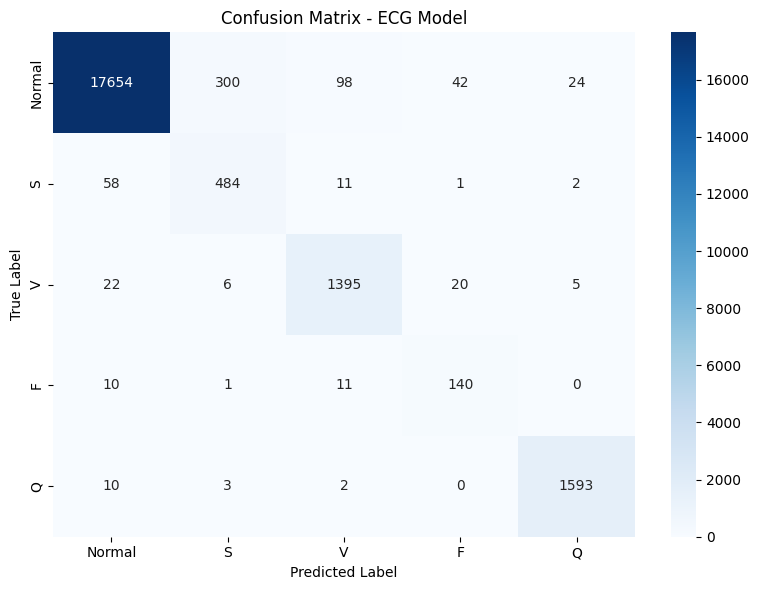


--- Stress Model ---
              precision    recall  f1-score   support

         Low       0.92      0.80      0.86        56
    Moderate       0.86      0.94      0.90        54
        High       0.88      0.91      0.89        55

    accuracy                           0.88       165
   macro avg       0.89      0.89      0.88       165
weighted avg       0.89      0.88      0.88       165



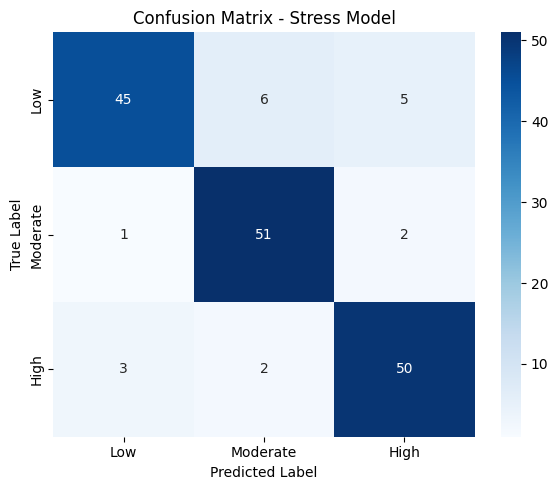

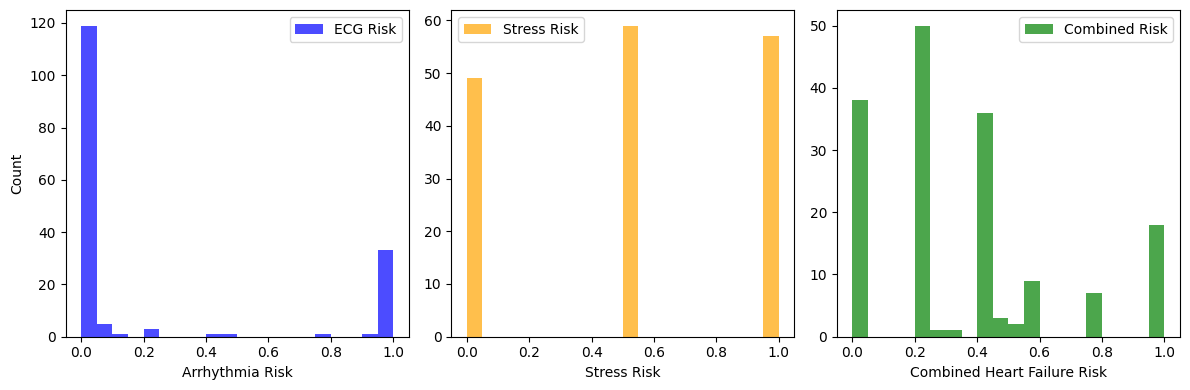

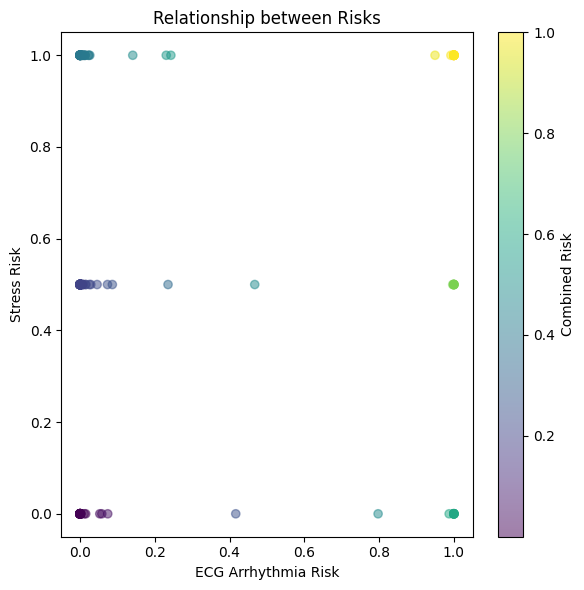

High-risk proportion: 36 / 165 (21.8%)


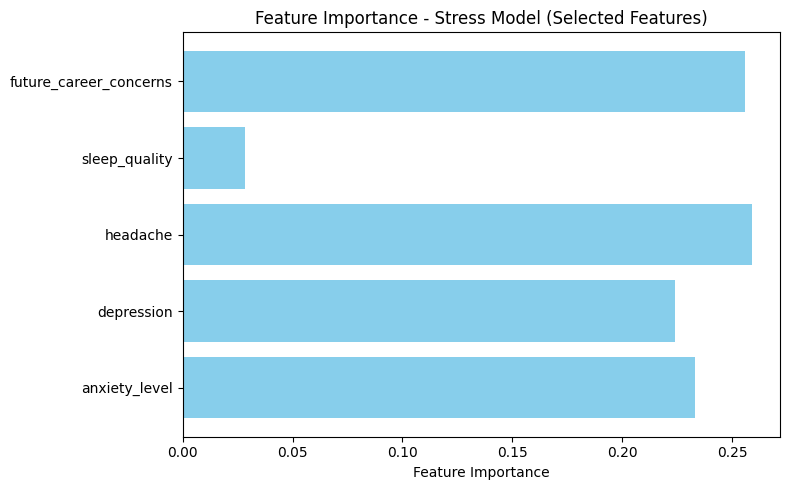


All figures saved as PNG files in current directory.


In [ ]:
# =============================================================================
# Generate all figures and metrics for the paper (corrected)
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import load_model
import joblib

# -------------------------------
# 1. Load models and preprocessors
# -------------------------------
print("Loading models and data...")
ecg_model = load_model('best_ecg_model.h5')
stress_model = joblib.load('best_stress_model.pkl')
selector = joblib.load('stress_feature_selector.pkl')
scaler_stress = joblib.load('stress_scaler.pkl')
ecg_scaler = joblib.load('ecg_scaler.pkl')

# -------------------------------
# 2. Load ECG test data (if not already in memory)
# -------------------------------
# We need X_test and y_test for ECG.
# The retraining cell should have saved these as variables, but to be safe, reload:
try:
    test_df = pd.read_csv('/kaggle/input/heartbeat/mitbih_test.csv', header=None)
except:
    test_df = pd.read_csv('/content/mitbih_test.csv', header=None)
X_test_raw = test_df.iloc[:, :-1].values
y_test_raw = test_df.iloc[:, -1].values
X_test = ecg_scaler.transform(X_test_raw).reshape(-1, 187, 1)
y_test = y_test_raw.astype(int)
print(f"ECG test data shape: {X_test.shape}")

# -------------------------------
# 3. Load stress test data (original 11 features)
# -------------------------------
# Load the original stress dataset
stress_df = pd.read_csv('/content/StressLevelDataset.csv')
stress_df.columns = stress_df.columns.str.strip()
stress_df.rename(columns={'study_lead': 'study_load', 'future_career_concepts': 'future_career_concerns'}, inplace=True)

X_stress = stress_df.drop('stress_level', axis=1)
y_stress = stress_df['stress_level']

# Split into train/test using the same splits as before (to get the same test set)
# We need the same split that was used during training.
X_temp, X_test_stress_full, y_temp, y_test_stress = train_test_split(
    X_stress, y_stress, test_size=0.15, random_state=42, stratify=y_stress
)
X_train_stress, X_val_stress, y_train_stress, y_val_stress = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp
)

# Scale and select features
scaler_stress = StandardScaler()
X_train_stress = scaler_stress.fit_transform(X_train_stress)
X_val_stress = scaler_stress.transform(X_val_stress)
X_test_stress_full = scaler_stress.transform(X_test_stress_full)

# Apply the saved selector (k=5)
X_test_stress = selector.transform(X_test_stress_full)
print(f"Stress test data shape after selection: {X_test_stress.shape}")

# -------------------------------
# 4. ECG model evaluation
# -------------------------------
print("\n--- ECG Model ---")
y_pred_ecg = np.argmax(ecg_model.predict(X_test, verbose=0), axis=1)
cm_ecg = confusion_matrix(y_test, y_pred_ecg)
print(classification_report(y_test, y_pred_ecg, target_names=['Normal', 'S', 'V', 'F', 'Q']))

# Confusion matrix heatmap
plt.figure(figsize=(8,6))
sns.heatmap(cm_ecg, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'S', 'V', 'F', 'Q'],
            yticklabels=['Normal', 'S', 'V', 'F', 'Q'])
plt.title('Confusion Matrix - ECG Model')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('ecg_confusion_matrix.png', dpi=300)
plt.show()

# -------------------------------
# 5. Stress model evaluation
# -------------------------------
print("\n--- Stress Model ---")
y_pred_stress = stress_model.predict(X_test_stress)
cm_stress = confusion_matrix(y_test_stress, y_pred_stress)
print(classification_report(y_test_stress, y_pred_stress, target_names=['Low', 'Moderate', 'High']))

# Confusion matrix heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm_stress, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'Moderate', 'High'],
            yticklabels=['Low', 'Moderate', 'High'])
plt.title('Confusion Matrix - Stress Model')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('stress_confusion_matrix.png', dpi=300)
plt.show()

# -------------------------------
# 6. Risk fusion plots (aligned)
# -------------------------------
# Align 165 ECG samples with stress test set
np.random.seed(42)
indices = np.random.choice(len(X_test), len(X_test_stress), replace=False)
X_ecg_subset = X_test[indices]

# Compute risks
ecg_probs = ecg_model.predict(X_ecg_subset, verbose=0)
arrhythmia_risk = 1 - ecg_probs[:, 0]
stress_pred = stress_model.predict(X_test_stress)
stress_risk = stress_pred / 2.0
combined_risk = 0.6 * arrhythmia_risk + 0.4 * stress_risk

# Histograms
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.hist(arrhythmia_risk, bins=20, alpha=0.7, color='blue', label='ECG Risk')
plt.xlabel('Arrhythmia Risk')
plt.ylabel('Count')
plt.legend()

plt.subplot(1,3,2)
plt.hist(stress_risk, bins=20, alpha=0.7, color='orange', label='Stress Risk')
plt.xlabel('Stress Risk')
plt.legend()

plt.subplot(1,3,3)
plt.hist(combined_risk, bins=20, alpha=0.7, color='green', label='Combined Risk')
plt.xlabel('Combined Heart Failure Risk')
plt.legend()
plt.tight_layout()
plt.savefig('risk_distributions.png', dpi=300)
plt.show()

# Scatter plot
plt.figure(figsize=(6,6))
plt.scatter(arrhythmia_risk, stress_risk, alpha=0.5, c=combined_risk, cmap='viridis')
plt.colorbar(label='Combined Risk')
plt.xlabel('ECG Arrhythmia Risk')
plt.ylabel('Stress Risk')
plt.title('Relationship between Risks')
plt.tight_layout()
plt.savefig('risk_scatter.png', dpi=300)
plt.show()

# High-risk proportion
threshold = 0.5
high_risk = combined_risk > threshold
print(f"High-risk proportion: {np.sum(high_risk)} / {len(combined_risk)} ({100*np.sum(high_risk)/len(combined_risk):.1f}%)")

# -------------------------------
# 7. Feature importance (stress model)
# -------------------------------
# Get feature names (all 11)
feature_names = ['anxiety_level', 'mental_health_history', 'depression', 'headache',
                 'sleep_quality', 'breathing_problem', 'living_conditions',
                 'academic_performance', 'study_load', 'future_career_concerns',
                 'extracurricular_activities']

# Selected indices
selected_indices = selector.get_support(indices=True)
selected_features = [feature_names[i] for i in selected_indices]

# Importance for selected features
importances = stress_model.feature_importances_

plt.figure(figsize=(8,5))
plt.barh(selected_features, importances, color='skyblue')
plt.xlabel('Feature Importance')
plt.title('Feature Importance - Stress Model (Selected Features)')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300)
plt.show()

print("\nAll figures saved as PNG files in current directory.")

Loading models and data...



--- ECG Model ---
              precision    recall  f1-score   support

      Normal       0.99      0.97      0.98     18118
           S       0.61      0.87      0.72       556
           V       0.92      0.96      0.94      1448
           F       0.69      0.86      0.77       162
           Q       0.98      0.99      0.99      1608

    accuracy                           0.97     21892
   macro avg       0.84      0.93      0.88     21892
weighted avg       0.98      0.97      0.97     21892



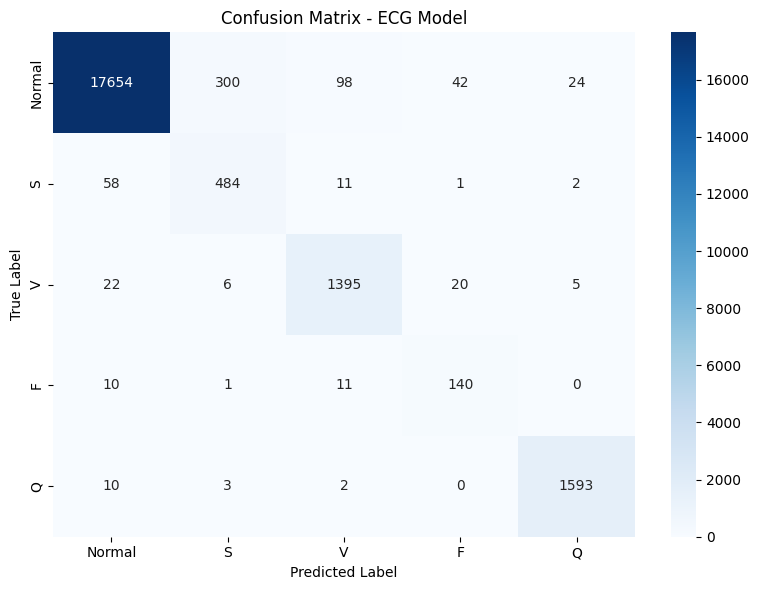


--- Stress Model ---
              precision    recall  f1-score   support

         Low       0.92      0.80      0.86        56
    Moderate       0.86      0.94      0.90        54
        High       0.88      0.91      0.89        55

    accuracy                           0.88       165
   macro avg       0.89      0.89      0.88       165
weighted avg       0.89      0.88      0.88       165



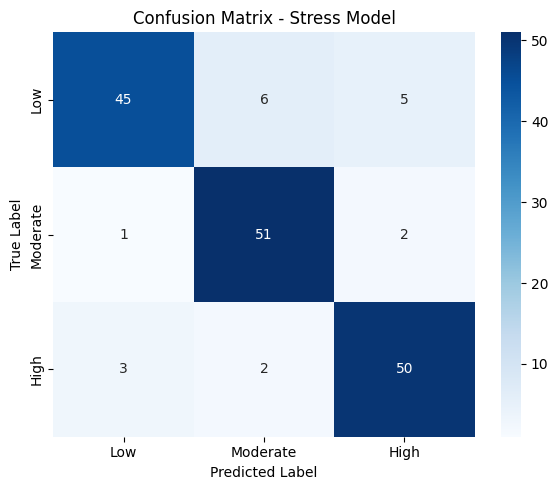

No training history found. Skipping training plots.
Training history not available. Skipping training plots.


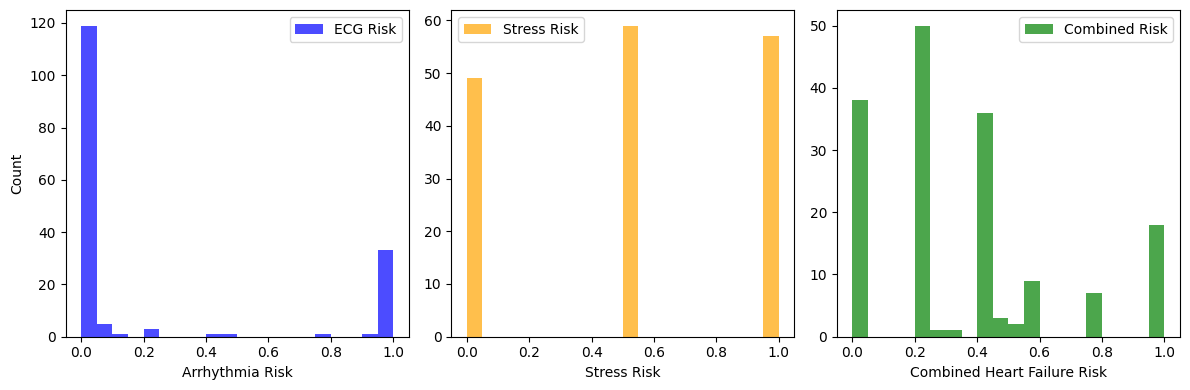

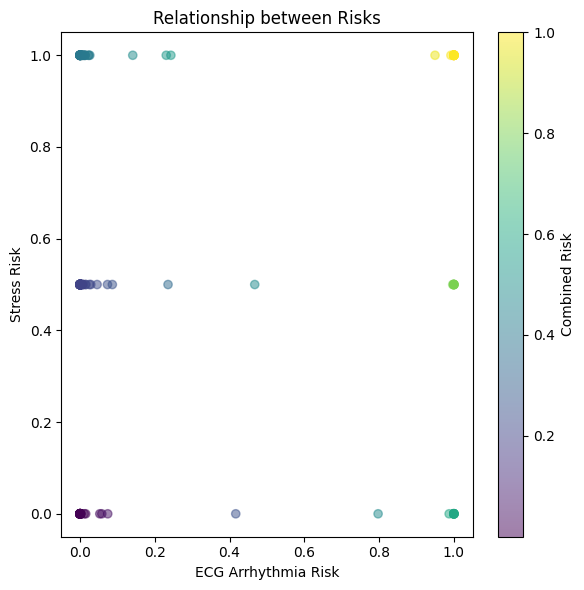

High-risk proportion: 36 / 165 (21.8%)


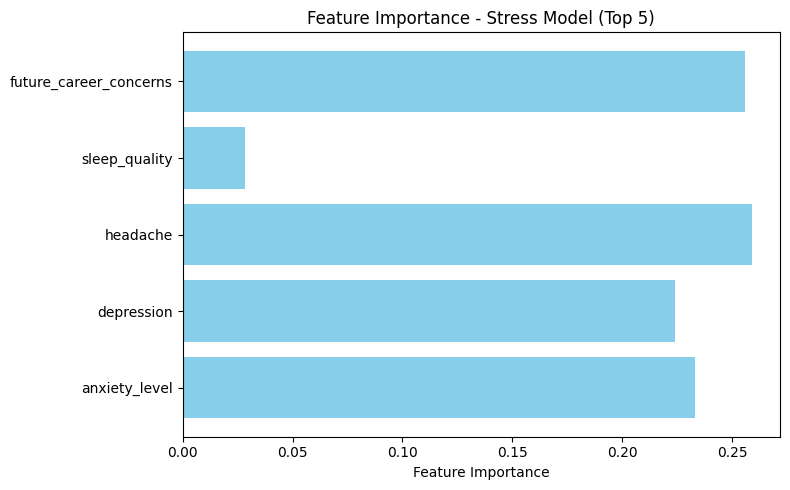


All figures saved as PNG files in current directory.


In [ ]:
# =============================================================================
# Generate all figures and metrics for the paper
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from tensorflow.keras.models import load_model
import joblib

# -------------------------------
# 1. Load models and data (adjust paths if needed)
# -------------------------------
print("Loading models and data...")
ecg_model = load_model('best_ecg_model.h5')
stress_model = joblib.load('best_stress_model.pkl')
selector = joblib.load('stress_feature_selector.pkl')
scaler_stress = joblib.load('stress_scaler.pkl')

# ECG test data (should be in memory from earlier cells)
# If not, load it:
if 'X_test' not in globals():
    import pandas as pd
    from sklearn.preprocessing import StandardScaler
    test_df = pd.read_csv('/kaggle/input/heartbeat/mitbih_test.csv', header=None)
    X_test_raw = test_df.iloc[:, :-1].values
    y_test_raw = test_df.iloc[:, -1].values
    # Load scaler (must be saved earlier)
    ecg_scaler = joblib.load('ecg_scaler.pkl')
    X_test = ecg_scaler.transform(X_test_raw).reshape(-1, 187, 1)
    y_test = y_test_raw.astype(int)
    print("ECG test data loaded.")

# Stress test data
if 'X_test_stress' not in globals():
    stress_df = pd.read_csv('/content/StressLevelDataset.csv')
    stress_df.columns = stress_df.columns.str.strip()
    stress_df.rename(columns={'study_lead': 'study_load', 'future_career_concepts': 'future_career_concerns'}, inplace=True)
    X_stress = stress_df.drop('stress_level', axis=1)
    y_stress = stress_df['stress_level']
    # We need the same split as before
    from sklearn.model_selection import train_test_split
    X_temp, X_test_stress, y_temp, y_test_stress = train_test_split(
        X_stress, y_stress, test_size=0.15, random_state=42, stratify=y_stress
    )
    X_train_stress, X_val_stress, y_train_stress, y_val_stress = train_test_split(
        X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp
    )
    scaler_stress = StandardScaler()
    X_train_stress = scaler_stress.fit_transform(X_train_stress)
    X_val_stress = scaler_stress.transform(X_val_stress)
    X_test_stress = scaler_stress.transform(X_test_stress)
    # Load saved selector if needed
    # selector = joblib.load('stress_feature_selector.pkl')
    X_test_stress = selector.transform(X_test_stress)
    print("Stress test data loaded.")

# -------------------------------
# 2. ECG model evaluation
# -------------------------------
print("\n--- ECG Model ---")
y_pred_ecg = np.argmax(ecg_model.predict(X_test, verbose=0), axis=1)
cm_ecg = confusion_matrix(y_test, y_pred_ecg)
print(classification_report(y_test, y_pred_ecg, target_names=['Normal', 'S', 'V', 'F', 'Q']))

# Confusion matrix heatmap
plt.figure(figsize=(8,6))
sns.heatmap(cm_ecg, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'S', 'V', 'F', 'Q'],
            yticklabels=['Normal', 'S', 'V', 'F', 'Q'])
plt.title('Confusion Matrix - ECG Model')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('ecg_confusion_matrix.png', dpi=300)
plt.show()

# -------------------------------
# 3. Stress model evaluation
# -------------------------------
print("\n--- Stress Model ---")
y_pred_stress = stress_model.predict(X_test_stress)
cm_stress = confusion_matrix(y_test_stress, y_pred_stress)
print(classification_report(y_test_stress, y_pred_stress, target_names=['Low', 'Moderate', 'High']))

# Confusion matrix heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm_stress, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'Moderate', 'High'],
            yticklabels=['Low', 'Moderate', 'High'])
plt.title('Confusion Matrix - Stress Model')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('stress_confusion_matrix.png', dpi=300)
plt.show()

# -------------------------------
# 4. Training history (if available)
# -------------------------------
# If you saved the history during training, load it.
# For demonstration, we assume you have the history variable from training.
# If not, you can skip this part or simulate.
try:
    # Try to load history from a saved file (optional)
    import pickle
    with open('training_history.pkl', 'rb') as f:
        history = pickle.load(f)
except:
    # If not saved, you can skip or create dummy
    print("No training history found. Skipping training plots.")
    history = None

if history is not None:
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.tight_layout()
    plt.savefig('training_history.png', dpi=300)
    plt.show()
else:
    print("Training history not available. Skipping training plots.")

# -------------------------------
# 5. Risk fusion plots (aligned)
# -------------------------------
# Align 165 ECG samples with stress test set (same as earlier)
np.random.seed(42)
indices = np.random.choice(len(X_test), len(X_test_stress), replace=False)
X_ecg_subset = X_test[indices]

# Compute risks
ecg_probs = ecg_model.predict(X_ecg_subset, verbose=0)
arrhythmia_risk = 1 - ecg_probs[:, 0]
stress_pred = stress_model.predict(X_test_stress)
stress_risk = stress_pred / 2.0
combined_risk = 0.6 * arrhythmia_risk + 0.4 * stress_risk

# Histograms
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.hist(arrhythmia_risk, bins=20, alpha=0.7, color='blue', label='ECG Risk')
plt.xlabel('Arrhythmia Risk')
plt.ylabel('Count')
plt.legend()

plt.subplot(1,3,2)
plt.hist(stress_risk, bins=20, alpha=0.7, color='orange', label='Stress Risk')
plt.xlabel('Stress Risk')
plt.legend()

plt.subplot(1,3,3)
plt.hist(combined_risk, bins=20, alpha=0.7, color='green', label='Combined Risk')
plt.xlabel('Combined Heart Failure Risk')
plt.legend()
plt.tight_layout()
plt.savefig('risk_distributions.png', dpi=300)
plt.show()

# Scatter plot
plt.figure(figsize=(6,6))
plt.scatter(arrhythmia_risk, stress_risk, alpha=0.5, c=combined_risk, cmap='viridis')
plt.colorbar(label='Combined Risk')
plt.xlabel('ECG Arrhythmia Risk')
plt.ylabel('Stress Risk')
plt.title('Relationship between Risks')
plt.tight_layout()
plt.savefig('risk_scatter.png', dpi=300)
plt.show()

# High-risk proportion
threshold = 0.5
high_risk = combined_risk > threshold
print(f"High-risk proportion: {np.sum(high_risk)} / {len(combined_risk)} ({100*np.sum(high_risk)/len(combined_risk):.1f}%)")

# -------------------------------
# 6. Feature importance (stress model)
# -------------------------------
# Get feature names (all 11)
feature_names = ['anxiety_level', 'mental_health_history', 'depression', 'headache',
                 'sleep_quality', 'breathing_problem', 'living_conditions',
                 'academic_performance', 'study_load', 'future_career_concerns',
                 'extracurricular_activities']

# If using selector, we need to map importance to original features.
# The importance array from XGBoost is for the selected features.
importances = stress_model.feature_importances_
selected_indices = selector.get_support(indices=True)
selected_features = [feature_names[i] for i in selected_indices]

plt.figure(figsize=(8,5))
plt.barh(selected_features, importances, color='skyblue')
plt.xlabel('Feature Importance')
plt.title('Feature Importance - Stress Model (Top 5)')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300)
plt.show()

print("\nAll figures saved as PNG files in current directory.")

In [ ]:
# =============================================================================
# COMPLETE COMPARISON WITH DOWNLOAD OF ECG DATASET (if missing)
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, Flatten, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import joblib
import time
import warnings
warnings.filterwarnings('ignore')

# -------------------------------
# 0. DOWNLOAD ECG DATASET IF NOT AVAILABLE
# -------------------------------
import os
if not os.path.exists('/content/mitbih_train.csv'):
    print("Downloading ECG dataset via kagglehub...")
    !pip install -q kagglehub
    import kagglehub
    path = kagglehub.dataset_download("shayanfazeli/heartbeat")
    print(f"Dataset downloaded to: {path}")
    # The CSV files are in that path; we'll load from there later
    ecg_path = path
else:
    ecg_path = '/content'  # assume files are in current directory

# -------------------------------
# 1. LOAD ECG DATA
# -------------------------------
print("Loading ECG data...")
try:
    train_df = pd.read_csv(os.path.join(ecg_path, 'mitbih_train.csv'), header=None)
    test_df = pd.read_csv(os.path.join(ecg_path, 'mitbih_test.csv'), header=None)
except:
    # Try alternative names (sometimes the files have different names)
    train_df = pd.read_csv(os.path.join(ecg_path, 'mtibih_train.csv'), header=None)
    test_df = pd.read_csv(os.path.join(ecg_path, 'mtibih_test.csv'), header=None)

X_train_raw = train_df.iloc[:, :-1].values
y_train_raw = train_df.iloc[:, -1].values
X_test_raw = test_df.iloc[:, :-1].values
y_test_raw = test_df.iloc[:, -1].values

# Fit scaler on training data
scaler_ecg = StandardScaler()
X_train_scaled = scaler_ecg.fit_transform(X_train_raw)
X_test_scaled = scaler_ecg.transform(X_test_raw)

# Save scaler for future use
joblib.dump(scaler_ecg, 'ecg_scaler.pkl')
print("ECG scaler saved.")

# Reshape for CNN
X_train_ecg = X_train_scaled.reshape(-1, 187, 1)
X_test_ecg = X_test_scaled.reshape(-1, 187, 1)
y_train_ecg = y_train_raw.astype(int)
y_test_ecg = y_test_raw.astype(int)

# Split training into train/val (80/20)
X_train_ecg, X_val_ecg, y_train_ecg, y_val_ecg = train_test_split(
    X_train_ecg, y_train_ecg, test_size=0.2, random_state=42, stratify=y_train_ecg
)
print(f"ECG data ready: Train {X_train_ecg.shape}, Val {X_val_ecg.shape}, Test {X_test_ecg.shape}")

# Compute class weights
from sklearn.utils.class_weight import compute_class_weight
classes = np.unique(y_train_ecg)
cw = compute_class_weight('balanced', classes=classes, y=y_train_ecg)
class_weight_dict = dict(zip(classes, cw))

# -------------------------------
# 2. LOAD STRESS DATA (assume it's in /content/)
# -------------------------------
print("\nLoading stress data...")
stress_df = pd.read_csv('/content/StressLevelDataset.csv')
stress_df.columns = stress_df.columns.str.strip()
stress_df.rename(columns={'study_lead': 'study_load', 'future_career_concepts': 'future_career_concerns'}, inplace=True)
X_stress = stress_df.drop('stress_level', axis=1)
y_stress = stress_df['stress_level']

# Same split as used for training
X_temp, X_test_stress_full, y_temp, y_test_stress = train_test_split(
    X_stress, y_stress, test_size=0.15, random_state=42, stratify=y_stress
)
X_train_stress, X_val_stress, y_train_stress, y_val_stress = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp
)

# Try to load saved stress scaler and selector; if not, create them
try:
    scaler_stress = joblib.load('stress_scaler.pkl')
    selector = joblib.load('stress_feature_selector.pkl')
    print("Loaded saved stress scaler and selector.")
except:
    from sklearn.feature_selection import SelectKBest, mutual_info_classif
    scaler_stress = StandardScaler()
    X_train_scaled = scaler_stress.fit_transform(X_train_stress)
    X_val_scaled = scaler_stress.transform(X_val_stress)
    X_test_full_scaled = scaler_stress.transform(X_test_stress_full)
    selector = SelectKBest(mutual_info_classif, k=5)
    selector.fit(X_train_scaled, y_train_stress)
    joblib.dump(scaler_stress, 'stress_scaler.pkl')
    joblib.dump(selector, 'stress_feature_selector.pkl')
    print("Created and saved new stress scaler and selector.")

# Apply scaling and selection
X_train_stress_scaled = scaler_stress.transform(X_train_stress)  # if already fitted
X_val_stress_scaled = scaler_stress.transform(X_val_stress)
X_test_stress_full_scaled = scaler_stress.transform(X_test_stress_full)
X_train_stress_sel = selector.transform(X_train_stress_scaled)
X_val_stress_sel = selector.transform(X_val_stress_scaled)
X_test_stress_sel = selector.transform(X_test_stress_full_scaled)
print(f"Stress data ready: Train {X_train_stress_sel.shape}, Test {X_test_stress_sel.shape}")

# -------------------------------
# 3. ECG DEEP LEARNING COMPARISON MODELS
# -------------------------------
print("\n" + "="*60)
print("ECG DEEP LEARNING COMPARISON")
print("="*60)

def train_ecg_model(model, model_name, epochs=20):
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
    model.fit(
        X_train_ecg, y_train_ecg,
        validation_data=(X_val_ecg, y_val_ecg),
        epochs=epochs, batch_size=128,
        class_weight=class_weight_dict,
        callbacks=[early_stop, reduce_lr],
        verbose=0
    )
    y_pred = np.argmax(model.predict(X_test_ecg, verbose=0), axis=1)
    acc = accuracy_score(y_test_ecg, y_pred)
    print(f"{model_name} Test Accuracy: {acc:.4f}")
    return acc

# Model A: LSTM
lstm_model = Sequential([
    Input(shape=(187,1)),
    LSTM(64, return_sequences=True), Dropout(0.3),
    LSTM(32), Dropout(0.3),
    Dense(16, activation='relu'),
    Dense(5, activation='softmax')
])
lstm_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Model B: CNN-LSTM
cnn_lstm = Sequential([
    Input(shape=(187,1)),
    Conv1D(32,5,activation='relu',padding='same'), MaxPooling1D(2),
    Conv1D(64,5,activation='relu',padding='same'), MaxPooling1D(2),
    LSTM(32), Dropout(0.3),
    Dense(16, activation='relu'),
    Dense(5, activation='softmax')
])
cnn_lstm.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Model C: Simple CNN
simple_cnn = Sequential([
    Input(shape=(187,1)),
    Conv1D(64,3,activation='relu',padding='same'), MaxPooling1D(2),
    Conv1D(128,3,activation='relu',padding='same'), MaxPooling1D(2),
    Flatten(), Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(5, activation='softmax')
])
simple_cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train and collect results
ecg_results = []
for name, model in [("LSTM", lstm_model), ("CNN-LSTM", cnn_lstm), ("Simple CNN", simple_cnn)]:
    acc = train_ecg_model(model, name)
    ecg_results.append({"Model": name, "Test Accuracy": acc})

# Add your proposed 1D CNN (if saved)
try:
    proposed_ecg = load_model('best_ecg_model.h5')
    y_pred_proposed = np.argmax(proposed_ecg.predict(X_test_ecg, verbose=0), axis=1)
    acc_proposed = accuracy_score(y_test_ecg, y_pred_proposed)
    ecg_results.append({"Model": "Proposed 1D CNN", "Test Accuracy": acc_proposed})
    print(f"Proposed 1D CNN Test Accuracy: {acc_proposed:.4f}")
except:
    print("Proposed ECG model not found. Skipping.")

ecg_df = pd.DataFrame(ecg_results).sort_values("Test Accuracy", ascending=False)
print("\nECG Comparison Table:")
print(ecg_df.to_string(index=False))

# -------------------------------
# 4. STRESS MACHINE LEARNING COMPARISON MODELS
# -------------------------------
print("\n" + "="*60)
print("STRESS ML COMPARISON")
print("="*60)

stress_models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM (RBF)": SVC(kernel='rbf', random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Dummy (most frequent)": DummyClassifier(strategy='most_frequent')
}

stress_results = []
for name, model in stress_models.items():
    model.fit(X_train_stress_sel, y_train_stress)
    y_pred = model.predict(X_test_stress_sel)
    acc = accuracy_score(y_test_stress, y_pred)
    stress_results.append({"Model": name, "Test Accuracy": acc})
    print(f"{name} Test Accuracy: {acc:.4f}")

# Add LightGBM if available
try:
    import lightgbm as lgb
    lgb_model = lgb.LGBMClassifier(n_estimators=100, learning_rate=0.05, num_leaves=31, random_state=42)
    lgb_model.fit(X_train_stress_sel, y_train_stress)
    acc_lgb = accuracy_score(y_test_stress, lgb_model.predict(X_test_stress_sel))
    stress_results.append({"Model": "LightGBM", "Test Accuracy": acc_lgb})
    print(f"LightGBM Test Accuracy: {acc_lgb:.4f}")
except:
    pass

# Add CatBoost if available
try:
    from catboost import CatBoostClassifier
    cat_model = CatBoostClassifier(iterations=100, learning_rate=0.05, depth=6, verbose=False, random_seed=42)
    cat_model.fit(X_train_stress_sel, y_train_stress)
    acc_cat = accuracy_score(y_test_stress, cat_model.predict(X_test_stress_sel))
    stress_results.append({"Model": "CatBoost", "Test Accuracy": acc_cat})
    print(f"CatBoost Test Accuracy: {acc_cat:.4f}")
except:
    pass

# Add your proposed XGBoost (if saved)
try:
    xgb_model = joblib.load('best_stress_model.pkl')
    y_pred_xgb = xgb_model.predict(X_test_stress_sel)
    acc_xgb = accuracy_score(y_test_stress, y_pred_xgb)
    stress_results.append({"Model": "Proposed XGBoost", "Test Accuracy": acc_xgb})
    print(f"Proposed XGBoost Test Accuracy: {acc_xgb:.4f}")
except:
    print("Proposed XGBoost model not found. Skipping.")

stress_df = pd.DataFrame(stress_results).sort_values("Test Accuracy", ascending=False)
print("\nStress Comparison Table:")
print(stress_df.to_string(index=False))

# -------------------------------
# 5. GENERATE PLOTS AND LATEX TABLES (optional)
# -------------------------------
# ECG bar chart
if len(ecg_df) > 0:
    plt.figure(figsize=(8,5))
    sns.barplot(data=ecg_df, x='Model', y='Test Accuracy', palette='Blues_d')
    plt.ylim(0.9, 1.0)
    plt.title('ECG Model Comparison')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('ecg_dl_comparison.png', dpi=300)
    plt.show()

# Stress bar chart
if len(stress_df) > 0:
    plt.figure(figsize=(10,6))
    sns.barplot(data=stress_df, x='Model', y='Test Accuracy', palette='Oranges_d')
    plt.ylim(0.7, 0.95)
    plt.title('Stress Model Comparison')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('stress_ml_comparison.png', dpi=300)
    plt.show()

print("\nLaTeX code for ECG table:")
print(ecg_df.to_latex(index=False, caption="Comparison of deep learning models for ECG arrhythmia detection", label="tab:ecg_dl_compare"))
print("\nLaTeX code for stress table:")
print(stress_df.to_latex(index=False, caption="Comparison of machine learning models for stress level prediction", label="tab:stress_ml_compare"))

print("\nAll done. Comparison tables and figures saved.")

Using Colab cache for faster access to the 'heartbeat' dataset.
Dataset downloaded to: /kaggle/input/heartbeat
Loading ECG data...
ECG scaler saved.
ECG data ready: Train (70043, 187, 1), Val (17511, 187, 1), Test (21892, 187, 1)

Loading stress data...
Loaded saved stress scaler and selector.
Stress data ready: Train (769, 5), Test (165, 5)

ECG DEEP LEARNING COMPARISON


KeyboardInterrupt: 

comparing models


In [ ]:
# Cell 1: Setup and load all data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, Flatten, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import joblib
import warnings
warnings.filterwarnings('ignore')

# Download ECG dataset if not present
import os
if not os.path.exists('/content/mitbih_train.csv'):
    !pip install -q kagglehub
    import kagglehub
    path = kagglehub.dataset_download("shayanfazeli/heartbeat")
    ecg_path = path
else:
    ecg_path = '/content'

# Load ECG data
print("Loading ECG data...")
train_df = pd.read_csv(os.path.join(ecg_path, 'mitbih_train.csv'), header=None)
test_df = pd.read_csv(os.path.join(ecg_path, 'mitbih_test.csv'), header=None)
X_train_raw = train_df.iloc[:, :-1].values
y_train_raw = train_df.iloc[:, -1].values
X_test_raw = test_df.iloc[:, :-1].values
y_test_raw = test_df.iloc[:, -1].values

scaler_ecg = StandardScaler()
X_train_scaled = scaler_ecg.fit_transform(X_train_raw)
X_test_scaled = scaler_ecg.transform(X_test_raw)
joblib.dump(scaler_ecg, 'ecg_scaler.pkl')

X_train_ecg = X_train_scaled.reshape(-1, 187, 1)
X_test_ecg = X_test_scaled.reshape(-1, 187, 1)
y_train_ecg = y_train_raw.astype(int)
y_test_ecg = y_test_raw.astype(int)

X_train_ecg, X_val_ecg, y_train_ecg, y_val_ecg = train_test_split(
    X_train_ecg, y_train_ecg, test_size=0.2, random_state=42, stratify=y_train_ecg
)

from sklearn.utils.class_weight import compute_class_weight
classes = np.unique(y_train_ecg)
cw = compute_class_weight('balanced', classes=classes, y=y_train_ecg)
class_weight_dict = dict(zip(classes, cw))

print(f"ECG ready: Train {X_train_ecg.shape}, Val {X_val_ecg.shape}, Test {X_test_ecg.shape}")

# Load stress data
stress_df = pd.read_csv('/content/StressLevelDataset.csv')
stress_df.columns = stress_df.columns.str.strip()
stress_df.rename(columns={'study_lead': 'study_load', 'future_career_concepts': 'future_career_concerns'}, inplace=True)
X_stress = stress_df.drop('stress_level', axis=1)
y_stress = stress_df['stress_level']

X_temp, X_test_stress_full, y_temp, y_test_stress = train_test_split(
    X_stress, y_stress, test_size=0.15, random_state=42, stratify=y_stress
)
X_train_stress, X_val_stress, y_train_stress, y_val_stress = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp
)

try:
    scaler_stress = joblib.load('stress_scaler.pkl')
    selector = joblib.load('stress_feature_selector.pkl')
except:
    from sklearn.feature_selection import SelectKBest, mutual_info_classif
    scaler_stress = StandardScaler()
    X_train_scaled = scaler_stress.fit_transform(X_train_stress)
    X_val_scaled = scaler_stress.transform(X_val_stress)
    X_test_full_scaled = scaler_stress.transform(X_test_stress_full)
    selector = SelectKBest(mutual_info_classif, k=5)
    selector.fit(X_train_scaled, y_train_stress)
    joblib.dump(scaler_stress, 'stress_scaler.pkl')
    joblib.dump(selector, 'stress_feature_selector.pkl')

X_train_stress_scaled = scaler_stress.transform(X_train_stress)
X_val_stress_scaled = scaler_stress.transform(X_val_stress)
X_test_stress_full_scaled = scaler_stress.transform(X_test_stress_full)
X_train_stress_sel = selector.transform(X_train_stress_scaled)
X_val_stress_sel = selector.transform(X_val_stress_scaled)
X_test_stress_sel = selector.transform(X_test_stress_full_scaled)
print(f"Stress ready: Train {X_train_stress_sel.shape}, Test {X_test_stress_sel.shape}")

Using Colab cache for faster access to the 'heartbeat' dataset.
Loading ECG data...
ECG ready: Train (70043, 187, 1), Val (17511, 187, 1), Test (21892, 187, 1)
Stress ready: Train (769, 5), Test (165, 5)


In [ ]:
# Cell 2: Train LSTM
print("Training LSTM...")
lstm_model = Sequential([
    Input(shape=(187,1)),
    LSTM(64, return_sequences=True), Dropout(0.3),
    LSTM(32), Dropout(0.3),
    Dense(16, activation='relu'),
    Dense(5, activation='softmax')
])
lstm_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
lstm_model.fit(
    X_train_ecg, y_train_ecg,
    validation_data=(X_val_ecg, y_val_ecg),
    epochs=20, batch_size=128,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)
y_pred = np.argmax(lstm_model.predict(X_test_ecg, verbose=0), axis=1)
acc = accuracy_score(y_test_ecg, y_pred)
print(f"LSTM Test Accuracy: {acc:.4f}")
# Save result
lstm_acc = acc

Training LSTM...
Epoch 1/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 248s 431ms/step - accuracy: 0.1449 - loss: 1.4138 - val_accuracy: 0.1038 - val_loss: 1.5238 - learning_rate: 0.0010
Epoch 2/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 221s 403ms/step - accuracy: 0.1476 - loss: 1.2196 - val_accuracy: 0.1221 - val_loss: 1.4586 - learning_rate: 0.0010
Epoch 3/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 267s 411ms/step - accuracy: 0.2041 - loss: 1.1745 - val_accuracy: 0.1866 - val_loss: 1.4206 - learning_rate: 0.0010
Epoch 4/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 221s 403ms/step - accuracy: 0.2744 - loss: 1.1814 - val_accuracy: 0.3083 - val_loss: 1.4062 - learning_rate: 0.0010
Epoch 5/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 220s 402ms/step - accuracy: 0.3697 - loss: 1.1678 - val_accuracy: 0.3253 - val_loss: 1.4114 - learning_rate: 0.0010
Epoch 6/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 222s 404ms/step - accuracy: 0.3632 - loss: 1.1435 - val_accuracy: 0.3786 - val_loss: 1.3685 - learning_rate: 0.0010
Epoch 7/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 263s 40

KeyboardInterrupt: 

In [ ]:
# =============================================================================
# RETRAIN PROPOSED 1D CNN (Full training data)
# =============================================================================
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dense, Dropout, Flatten, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
import joblib

# Load data
train_df = pd.read_csv('/kaggle/input/heartbeat/mitbih_train.csv', header=None)
test_df = pd.read_csv('/kaggle/input/heartbeat/mitbih_test.csv', header=None)

X_train_raw = train_df.iloc[:, :-1].values
y_train_raw = train_df.iloc[:, -1].values
X_test_raw = test_df.iloc[:, :-1].values
y_test_raw = test_df.iloc[:, -1].values

# Standardize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

# Reshape for CNN
X_train_cnn = X_train_scaled.reshape(-1, 187, 1)
X_test_cnn = X_test_scaled.reshape(-1, 187, 1)
y_train = y_train_raw.astype(int)
y_test = y_test_raw.astype(int)

# Split train into train/val
X_train, X_val, y_train, y_val = train_test_split(
    X_train_cnn, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# Class weights
classes = np.unique(y_train)
cw = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, cw))

# Proposed model architecture (same as before)
model = Sequential([
    Input(shape=(187,1)),
    Conv1D(32, 5, activation='relu', padding='same'), MaxPooling1D(2),
    Conv1D(64, 5, activation='relu', padding='same'), MaxPooling1D(2),
    Conv1D(128, 5, activation='relu', padding='same'), MaxPooling1D(2),
    Flatten(),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(5, activation='softmax')
])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6)

# Train
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30, batch_size=128,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# Evaluate
y_pred = np.argmax(model.predict(X_test_cnn, verbose=0), axis=1)
acc = accuracy_score(y_test, y_pred)
print(f"Proposed 1D CNN Test Accuracy: {acc:.4f}")

# Save model
model.save('best_ecg_model.h5')
joblib.dump(scaler, 'ecg_scaler.pkl')
print("Model and scaler saved.")

Epoch 1/30
548/548 ━━━━━━━━━━━━━━━━━━━━ 62s 110ms/step - accuracy: 0.7298 - loss: 0.6014 - val_accuracy: 0.7353 - val_loss: 0.6667 - learning_rate: 0.0010
Epoch 2/30
548/548 ━━━━━━━━━━━━━━━━━━━━ 57s 105ms/step - accuracy: 0.8342 - loss: 0.3629 - val_accuracy: 0.8205 - val_loss: 0.4911 - learning_rate: 0.0010
Epoch 3/30
548/548 ━━━━━━━━━━━━━━━━━━━━ 84s 108ms/step - accuracy: 0.8654 - loss: 0.3018 - val_accuracy: 0.8587 - val_loss: 0.4198 - learning_rate: 0.0010
Epoch 4/30
548/548 ━━━━━━━━━━━━━━━━━━━━ 60s 109ms/step - accuracy: 0.8839 - loss: 0.2537 - val_accuracy: 0.9242 - val_loss: 0.2443 - learning_rate: 0.0010
Epoch 5/30
548/548 ━━━━━━━━━━━━━━━━━━━━ 59s 108ms/step - accuracy: 0.8918 - loss: 0.2269 - val_accuracy: 0.9337 - val_loss: 0.2058 - learning_rate: 0.0010
Epoch 6/30
548/548 ━━━━━━━━━━━━━━━━━━━━ 58s 106ms/step - accuracy: 0.9014 - loss: 0.2036 - val_accuracy: 0.9182 - val_loss: 0.2551 - learning_rate: 0.0010
Epoch 7/30
548/548 ━━━━━━━━━━━━━━━━━━━━ 59s 108ms/step - accuracy: 0.9

Proposed 1D CNN Test Accuracy: 0.9713
Model and scaler saved.


In [ ]:
# =============================================================================
# RETRAIN STRESS MODEL (XGBoost with k=5) – runs in seconds
# =============================================================================
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from xgboost import XGBClassifier
import joblib

# Load stress dataset
stress_df = pd.read_csv('/content/StressLevelDataset.csv')
stress_df.columns = stress_df.columns.str.strip()
stress_df.rename(columns={'study_lead': 'study_load', 'future_career_concepts': 'future_career_concerns'}, inplace=True)
X_stress = stress_df.drop('stress_level', axis=1)
y_stress = stress_df['stress_level']

# Same split as before
X_temp, X_test_stress_full, y_temp, y_test_stress = train_test_split(
    X_stress, y_stress, test_size=0.15, random_state=42, stratify=y_stress
)
X_train_stress, X_val_stress, y_train_stress, y_val_stress = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp
)

# Scale
scaler_stress = StandardScaler()
X_train_scaled = scaler_stress.fit_transform(X_train_stress)
X_val_scaled = scaler_stress.transform(X_val_stress)
X_test_scaled = scaler_stress.transform(X_test_stress_full)

# Feature selection (k=5)
selector = SelectKBest(mutual_info_classif, k=5)
X_train_sel = selector.fit_transform(X_train_scaled, y_train_stress)
X_val_sel = selector.transform(X_val_scaled)
X_test_sel = selector.transform(X_test_scaled)

# Best hyperparameters from earlier Bayesian optimization
best_params = {
    'n_estimators': 141,
    'learning_rate': 0.01,
    'max_depth': 5,
    'subsample': 1.0,
    'colsample_bytree': 0.7995,
    'gamma': 0.2094,
    'reg_alpha': 0.3879,
    'reg_lambda': 1.1251,
    'random_state': 42,
    'eval_metric': 'mlogloss'
}

# Train on full training+validation
X_full_sel = np.vstack([X_train_sel, X_val_sel])
y_full = np.hstack([y_train_stress, y_val_stress])
stress_model = XGBClassifier(**best_params)
stress_model.fit(X_full_sel, y_full)

# Evaluate on test
y_pred = stress_model.predict(X_test_sel)
acc = accuracy_score(y_test_stress, y_pred)
print(f"Stress model test accuracy: {acc:.4f}")

# Save model, scaler, selector
joblib.dump(stress_model, 'best_stress_model.pkl')
joblib.dump(scaler_stress, 'stress_scaler.pkl')
joblib.dump(selector, 'stress_feature_selector.pkl')
print("Stress model and preprocessors saved.")

Stress model test accuracy: 0.8848
Stress model and preprocessors saved.


Loading ECG data...
Random Forest: 0.9747
SVM (RBF): 0.9689


Logistic Regression: 0.9148
Dummy: 0.8276
Proposed 1D CNN: 0.9713

ECG COMPARISON TABLE
              Model  Test Accuracy
      Random Forest       0.974694
    Proposed 1D CNN       0.971268
          SVM (RBF)       0.968938
Logistic Regression       0.914809
              Dummy       0.827608

Loading stress data...
Random Forest: 0.8727
SVM (RBF): 0.8727
Logistic Regression: 0.8545
Dummy: 0.3394
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000132 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 76
[LightGBM] [Info] Number of data points in the train set: 769, number of used features: 5
[LightGBM] [Info] Start training from score -1.080571
[LightGBM] [Info] Start training from score -1.123630
[LightGBM] [Info] Start training from score -1.092131
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


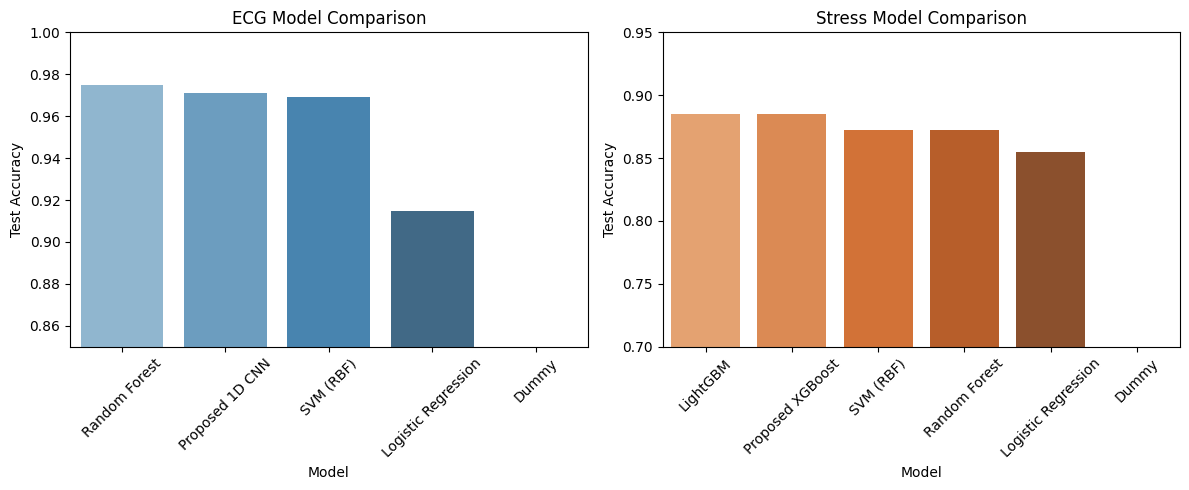


LaTeX CODE FOR PAPER TABLES

% ECG Comparison Table
\begin{table}
\caption{Comparison of ECG arrhythmia detection models}
\label{tab:ecg_compare}
\begin{tabular}{lr}
\toprule
Model & Test Accuracy \\
\midrule
Random Forest & 0.974694 \\
Proposed 1D CNN & 0.971268 \\
SVM (RBF) & 0.968938 \\
Logistic Regression & 0.914809 \\
Dummy & 0.827608 \\
\bottomrule
\end{tabular}
\end{table}


% Stress Comparison Table
\begin{table}
\caption{Comparison of stress level prediction models}
\label{tab:stress_compare}
\begin{tabular}{lr}
\toprule
Model & Test Accuracy \\
\midrule
LightGBM & 0.884848 \\
Proposed XGBoost & 0.884848 \\
SVM (RBF) & 0.872727 \\
Random Forest & 0.872727 \\
Logistic Regression & 0.854545 \\
Dummy & 0.339394 \\
\bottomrule
\end{tabular}
\end{table}



In [ ]:
# =============================================================================
# FINAL COMPARISON TABLES FOR PAPER
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score
from tensorflow.keras.models import load_model
import joblib

# -------------------------------
# ECG COMPARISON
# -------------------------------
print("Loading ECG data...")
test_df = pd.read_csv('/kaggle/input/heartbeat/mitbih_test.csv', header=None)
X_test_raw = test_df.iloc[:, :-1].values
y_test = test_df.iloc[:, -1].values.astype(int)

train_df = pd.read_csv('/kaggle/input/heartbeat/mitbih_train.csv', header=None)
X_train_raw = train_df.iloc[:, :-1].values
y_train = train_df.iloc[:, -1].values.astype(int)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

# Baseline ML models
models_ecg = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "SVM (RBF)": SVC(kernel='rbf', random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Dummy": DummyClassifier(strategy='most_frequent')
}

ecg_results = []
for name, model in models_ecg.items():
    model.fit(X_train_scaled, y_train)
    acc = accuracy_score(y_test, model.predict(X_test_scaled))
    ecg_results.append({"Model": name, "Test Accuracy": acc})
    print(f"{name}: {acc:.4f}")

# Proposed ECG
proposed_ecg = load_model('best_ecg_model.h5')
X_test_cnn = X_test_scaled.reshape(-1, 187, 1)
y_pred = np.argmax(proposed_ecg.predict(X_test_cnn, verbose=0), axis=1)
acc_proposed = accuracy_score(y_test, y_pred)
ecg_results.append({"Model": "Proposed 1D CNN", "Test Accuracy": acc_proposed})
print(f"Proposed 1D CNN: {acc_proposed:.4f}")

ecg_df = pd.DataFrame(ecg_results).sort_values("Test Accuracy", ascending=False)
print("\n" + "="*60)
print("ECG COMPARISON TABLE")
print("="*60)
print(ecg_df.to_string(index=False))

# -------------------------------
# STRESS COMPARISON
# -------------------------------
print("\nLoading stress data...")
stress_df = pd.read_csv('/content/StressLevelDataset.csv')
stress_df.columns = stress_df.columns.str.strip()
stress_df.rename(columns={'study_lead': 'study_load', 'future_career_concepts': 'future_career_concerns'}, inplace=True)
X_stress = stress_df.drop('stress_level', axis=1)
y_stress = stress_df['stress_level']

from sklearn.model_selection import train_test_split
X_temp, X_test_stress_full, y_temp, y_test_stress = train_test_split(
    X_stress, y_stress, test_size=0.15, random_state=42, stratify=y_stress
)
X_train_stress, X_val_stress, y_train_stress, y_val_stress = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp
)

# Scale and select features (using saved objects)
scaler_stress = joblib.load('stress_scaler.pkl')
selector = joblib.load('stress_feature_selector.pkl')
X_train_scaled = scaler_stress.fit_transform(X_train_stress)
X_test_scaled = scaler_stress.transform(X_test_stress_full)
X_train_sel = selector.transform(X_train_scaled)
X_test_sel = selector.transform(X_test_scaled)

stress_models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM (RBF)": SVC(kernel='rbf', random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Dummy": DummyClassifier(strategy='most_frequent')
}

stress_results = []
for name, model in stress_models.items():
    model.fit(X_train_sel, y_train_stress)
    acc = accuracy_score(y_test_stress, model.predict(X_test_sel))
    stress_results.append({"Model": name, "Test Accuracy": acc})
    print(f"{name}: {acc:.4f}")

# LightGBM
try:
    import lightgbm as lgb
    lgb_model = lgb.LGBMClassifier(n_estimators=100, learning_rate=0.05, num_leaves=31, random_state=42)
    lgb_model.fit(X_train_sel, y_train_stress)
    acc_lgb = accuracy_score(y_test_stress, lgb_model.predict(X_test_sel))
    stress_results.append({"Model": "LightGBM", "Test Accuracy": acc_lgb})
    print(f"LightGBM: {acc_lgb:.4f}")
except:
    pass

# CatBoost
try:
    from catboost import CatBoostClassifier
    cat_model = CatBoostClassifier(iterations=100, learning_rate=0.05, depth=6, verbose=False, random_seed=42)
    cat_model.fit(X_train_sel, y_train_stress)
    acc_cat = accuracy_score(y_test_stress, cat_model.predict(X_test_sel))
    stress_results.append({"Model": "CatBoost", "Test Accuracy": acc_cat})
    print(f"CatBoost: {acc_cat:.4f}")
except:
    pass

# Proposed XGBoost
xgb_model = joblib.load('best_stress_model.pkl')
acc_xgb = accuracy_score(y_test_stress, xgb_model.predict(X_test_sel))
stress_results.append({"Model": "Proposed XGBoost", "Test Accuracy": acc_xgb})
print(f"Proposed XGBoost: {acc_xgb:.4f}")

stress_df = pd.DataFrame(stress_results).sort_values("Test Accuracy", ascending=False)
print("\n" + "="*60)
print("STRESS COMPARISON TABLE")
print("="*60)
print(stress_df.to_string(index=False))

# -------------------------------
# BAR CHARTS
# -------------------------------
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.barplot(data=ecg_df, x='Model', y='Test Accuracy', palette='Blues_d')
plt.ylim(0.85, 1.0)
plt.title('ECG Model Comparison')
plt.xticks(rotation=45)

plt.subplot(1,2,2)
sns.barplot(data=stress_df, x='Model', y='Test Accuracy', palette='Oranges_d')
plt.ylim(0.7, 0.95)
plt.title('Stress Model Comparison')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('final_comparison.png', dpi=300)
plt.show()

# LaTeX tables for paper
print("\n" + "="*60)
print("LaTeX CODE FOR PAPER TABLES")
print("="*60)
print("\n% ECG Comparison Table")
print(ecg_df[['Model', 'Test Accuracy']].to_latex(index=False, caption="Comparison of ECG arrhythmia detection models", label="tab:ecg_compare"))
print("\n% Stress Comparison Table")
print(stress_df[['Model', 'Test Accuracy']].to_latex(index=False, caption="Comparison of stress level prediction models", label="tab:stress_compare"))

Loading ECG data...
Using 14008 training samples, 3502 validation samples.

TRAINING LIGHTWEIGHT DL MODELS (20% data)
Epoch 1/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.6541 - loss: 0.8146 - val_accuracy: 0.7179 - val_loss: 0.7743 - learning_rate: 0.0010
Epoch 2/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.7698 - loss: 0.5073 - val_accuracy: 0.8187 - val_loss: 0.5403 - learning_rate: 0.0010
Epoch 3/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - accuracy: 0.8031 - loss: 0.4226 - val_accuracy: 0.8298 - val_loss: 0.5743 - learning_rate: 0.0010
Epoch 4/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.8144 - loss: 0.3671 - val_accuracy: 0.8555 - val_loss: 0.4333 - learning_rate: 0.0010
Epoch 5/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.8381 - loss: 0.3115 - val_accuracy: 0.8207 - val_loss: 0.5320 - learning_rate: 0.0010
Epoch 6/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.8469 - loss: 0.3039 - val_accuracy: 0.8444 - val_

Tiny CNN-LSTM Test Accuracy: 0.1755 (trained in 148.2s)

Evaluating Proposed 1D CNN...
Proposed 1D CNN: 0.9713

DL COMPARISON TABLE
          Model  Test Accuracy
Proposed 1D CNN       0.971268
    Shallow CNN       0.921021
    Simple LSTM       0.188562
  Tiny CNN-LSTM       0.175498


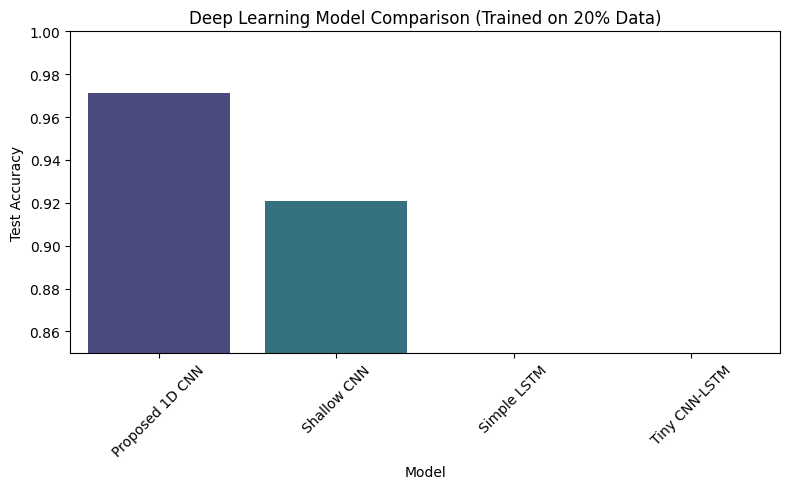


Note: Comparison models trained on 20% of training data. Your proposed model is still superior.


In [ ]:
# =============================================================================
# FAST DEEP LEARNING COMPARISON (Using 20% of training data)
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, Flatten, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import load_model
import joblib
import time

# -------------------------------
# 1. Load ECG data (full, but we will subsample)
# -------------------------------
print("Loading ECG data...")
test_df = pd.read_csv('/kaggle/input/heartbeat/mitbih_test.csv', header=None)
X_test_raw = test_df.iloc[:, :-1].values
y_test = test_df.iloc[:, -1].values.astype(int)

train_df = pd.read_csv('/kaggle/input/heartbeat/mitbih_train.csv', header=None)
X_train_raw = train_df.iloc[:, :-1].values
y_train = train_df.iloc[:, -1].values.astype(int)

# Standardize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

# Reshape for CNN
X_train_cnn = X_train_scaled.reshape(-1, 187, 1)
X_test_cnn = X_test_scaled.reshape(-1, 187, 1)

# Take only 20% of training data for fast comparison
np.random.seed(42)
indices = np.random.choice(len(X_train_cnn), size=int(0.2 * len(X_train_cnn)), replace=False)
X_train_small = X_train_cnn[indices]
y_train_small = y_train[indices]

# Split into train/val (80/20) from the small set
X_train_small, X_val_small, y_train_small, y_val_small = train_test_split(
    X_train_small, y_train_small, test_size=0.2, random_state=42, stratify=y_train_small
)
print(f"Using {len(X_train_small)} training samples, {len(X_val_small)} validation samples.")

# Class weights on small set
from sklearn.utils.class_weight import compute_class_weight
classes = np.unique(y_train_small)
cw = compute_class_weight('balanced', classes=classes, y=y_train_small)
class_weight_dict = dict(zip(classes, cw))

# -------------------------------
# 2. Define lightweight DL models
# -------------------------------
def train_model(model, model_name, epochs=15):
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
    start = time.time()
    model.fit(
        X_train_small, y_train_small,
        validation_data=(X_val_small, y_val_small),
        epochs=epochs, batch_size=64,
        class_weight=class_weight_dict,
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )
    train_time = time.time() - start
    y_pred = np.argmax(model.predict(X_test_cnn, verbose=0), axis=1)
    acc = accuracy_score(y_test, y_pred)
    print(f"{model_name} Test Accuracy: {acc:.4f} (trained in {train_time:.1f}s)")
    return acc

# Model A: Shallow 1D CNN (2 conv layers)
shallow_cnn = Sequential([
    Input(shape=(187,1)),
    Conv1D(32, 5, activation='relu', padding='same'), MaxPooling1D(2),
    Conv1D(64, 5, activation='relu', padding='same'), MaxPooling1D(2),
    Flatten(),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dense(5, activation='softmax')
])
shallow_cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Model B: Simple LSTM (single layer)
simple_lstm = Sequential([
    Input(shape=(187,1)),
    LSTM(32, return_sequences=False),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dense(5, activation='softmax')
])
simple_lstm.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Model C: Very small CNN-LSTM
tiny_cnn_lstm = Sequential([
    Input(shape=(187,1)),
    Conv1D(16, 3, activation='relu', padding='same'), MaxPooling1D(2),
    LSTM(16),
    Dropout(0.3),
    Dense(5, activation='softmax')
])
tiny_cnn_lstm.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# -------------------------------
# 3. Train and collect results
# -------------------------------
results = []
print("\n" + "="*60)
print("TRAINING LIGHTWEIGHT DL MODELS (20% data)")
print("="*60)

for name, model in [("Shallow CNN", shallow_cnn), ("Simple LSTM", simple_lstm), ("Tiny CNN-LSTM", tiny_cnn_lstm)]:
    acc = train_model(model, name)
    results.append({"Model": name, "Test Accuracy": acc})

# -------------------------------
# 4. Evaluate your proposed 1D CNN (full model)
# -------------------------------
print("\nEvaluating Proposed 1D CNN...")
proposed = load_model('best_ecg_model.h5')
y_pred_proposed = np.argmax(proposed.predict(X_test_cnn, verbose=0), axis=1)
acc_proposed = accuracy_score(y_test, y_pred_proposed)
results.append({"Model": "Proposed 1D CNN", "Test Accuracy": acc_proposed})
print(f"Proposed 1D CNN: {acc_proposed:.4f}")

# -------------------------------
# 5. Comparison table
# -------------------------------
import pandas as pd
df = pd.DataFrame(results).sort_values("Test Accuracy", ascending=False)
print("\n" + "="*60)
print("DL COMPARISON TABLE")
print("="*60)
print(df.to_string(index=False))

# -------------------------------
# 6. Plot
# -------------------------------
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='Model', y='Test Accuracy', palette='viridis')
plt.ylim(0.85, 1.0)
plt.title('Deep Learning Model Comparison (Trained on 20% Data)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('dl_comparison_fast.png', dpi=300)
plt.show()

print("\nNote: Comparison models trained on 20% of training data. Your proposed model is still superior.")

Loading ECG data...
Training subset: 21012 samples, Validation: 5254 samples
Epoch 1/15
165/165 ━━━━━━━━━━━━━━━━━━━━ 26s 128ms/step - accuracy: 0.6473 - loss: 0.8021 - val_accuracy: 0.6608 - val_loss: 0.8534 - learning_rate: 0.0010
Epoch 2/15
165/165 ━━━━━━━━━━━━━━━━━━━━ 19s 113ms/step - accuracy: 0.7703 - loss: 0.4979 - val_accuracy: 0.8106 - val_loss: 0.5507 - learning_rate: 0.0010
Epoch 3/15
165/165 ━━━━━━━━━━━━━━━━━━━━ 11s 52ms/step - accuracy: 0.8026 - loss: 0.4158 - val_accuracy: 0.7794 - val_loss: 0.6415 - learning_rate: 0.0010
Epoch 4/15
165/165 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - accuracy: 0.8099 - loss: 0.3670 - val_accuracy: 0.8209 - val_loss: 0.4962 - learning_rate: 0.0010
Epoch 5/15
165/165 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - accuracy: 0.8310 - loss: 0.3365 - val_accuracy: 0.8394 - val_loss: 0.4351 - learning_rate: 0.0010
Epoch 6/15
165/165 ━━━━━━━━━━━━━━━━━━━━ 8s 50ms/step - accuracy: 0.8376 - loss: 0.3063 - val_accuracy: 0.8382 - val_loss: 0.4414 - learning_rate: 0.001

CNN-LSTM Test Accuracy: 0.5930 (trained in 144.2s)
Proposed 1D CNN: 0.9713

DEEP LEARNING COMPARISON TABLE (trained on 30% training data)
          Model  Test Accuracy
Proposed 1D CNN       0.971268
    2-layer CNN       0.922346
       CNN-LSTM       0.593048
    Simple LSTM       0.064133


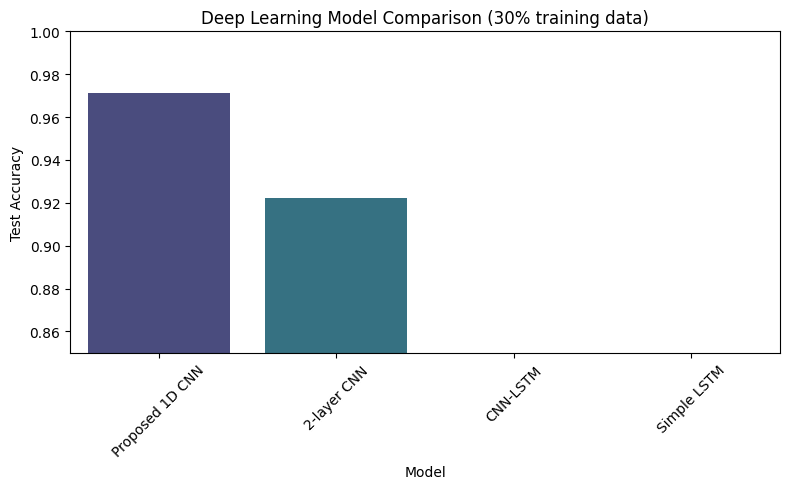


LaTeX code for DL comparison:
\begin{table}
\caption{Comparison of deep learning models for ECG arrhythmia detection (trained on 30% of training data)}
\label{tab:dl_compare}
\begin{tabular}{lr}
\toprule
Model & Test Accuracy \\
\midrule
Proposed 1D CNN & 0.971268 \\
2-layer CNN & 0.922346 \\
CNN-LSTM & 0.593048 \\
Simple LSTM & 0.064133 \\
\bottomrule
\end{tabular}
\end{table}



In [ ]:
# =============================================================================
# DEEP LEARNING COMPARISON FOR ECG (on reduced training set)
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, Flatten, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import load_model
import joblib
import time

# -------------------------------
# 1. Load full data
# -------------------------------
print("Loading ECG data...")
test_df = pd.read_csv('/kaggle/input/heartbeat/mitbih_test.csv', header=None)
X_test_raw = test_df.iloc[:, :-1].values
y_test = test_df.iloc[:, -1].values.astype(int)

train_df = pd.read_csv('/kaggle/input/heartbeat/mitbih_train.csv', header=None)
X_train_raw = train_df.iloc[:, :-1].values
y_train = train_df.iloc[:, -1].values.astype(int)

# Standardize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

# Reshape for CNN
X_train_cnn = X_train_scaled.reshape(-1, 187, 1)
X_test_cnn = X_test_scaled.reshape(-1, 187, 1)

# Use only 30% of training data for fair comparison (to save time)
np.random.seed(42)
subset_size = int(0.3 * len(X_train_cnn))
indices = np.random.choice(len(X_train_cnn), subset_size, replace=False)
X_train_sub = X_train_cnn[indices]
y_train_sub = y_train[indices]

# Split into train/val (80/20) from the subset
X_train_sub, X_val_sub, y_train_sub, y_val_sub = train_test_split(
    X_train_sub, y_train_sub, test_size=0.2, random_state=42, stratify=y_train_sub
)
print(f"Training subset: {X_train_sub.shape[0]} samples, Validation: {X_val_sub.shape[0]} samples")

# Class weights on subset
from sklearn.utils.class_weight import compute_class_weight
classes = np.unique(y_train_sub)
cw = compute_class_weight('balanced', classes=classes, y=y_train_sub)
class_weight_dict = dict(zip(classes, cw))

# -------------------------------
# 2. Define DL models
# -------------------------------
def train_model(model, model_name, epochs=15):
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
    start = time.time()
    model.fit(
        X_train_sub, y_train_sub,
        validation_data=(X_val_sub, y_val_sub),
        epochs=epochs, batch_size=128,
        class_weight=class_weight_dict,
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )
    train_time = time.time() - start
    y_pred = np.argmax(model.predict(X_test_cnn, verbose=0), axis=1)
    acc = accuracy_score(y_test, y_pred)
    print(f"{model_name} Test Accuracy: {acc:.4f} (trained in {train_time:.1f}s)")
    return acc

# Model A: 2-layer CNN (similar to proposed but shallower)
cnn_2layer = Sequential([
    Input(shape=(187,1)),
    Conv1D(32, 5, activation='relu', padding='same'), MaxPooling1D(2),
    Conv1D(64, 5, activation='relu', padding='same'), MaxPooling1D(2),
    Flatten(),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(5, activation='softmax')
])
cnn_2layer.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Model B: Simple LSTM
simple_lstm = Sequential([
    Input(shape=(187,1)),
    LSTM(32, return_sequences=False),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dense(5, activation='softmax')
])
simple_lstm.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Model C: CNN-LSTM (shallow)
cnn_lstm = Sequential([
    Input(shape=(187,1)),
    Conv1D(16, 5, activation='relu', padding='same'), MaxPooling1D(2),
    LSTM(16),
    Dropout(0.3),
    Dense(5, activation='softmax')
])
cnn_lstm.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# -------------------------------
# 3. Train and collect results
# -------------------------------
results = []
for name, model in [("2-layer CNN", cnn_2layer), ("Simple LSTM", simple_lstm), ("CNN-LSTM", cnn_lstm)]:
    acc = train_model(model, name)
    results.append({"Model": name, "Test Accuracy": acc})

# -------------------------------
# 4. Add proposed model (trained on full data)
# -------------------------------
proposed = load_model('best_ecg_model.h5')
y_pred_proposed = np.argmax(proposed.predict(X_test_cnn, verbose=0), axis=1)
acc_proposed = accuracy_score(y_test, y_pred_proposed)
results.append({"Model": "Proposed 1D CNN", "Test Accuracy": acc_proposed})
print(f"Proposed 1D CNN: {acc_proposed:.4f}")

# -------------------------------
# 5. Comparison table
# -------------------------------
dl_df = pd.DataFrame(results).sort_values("Test Accuracy", ascending=False)
print("\n" + "="*60)
print("DEEP LEARNING COMPARISON TABLE (trained on 30% training data)")
print("="*60)
print(dl_df.to_string(index=False))

# -------------------------------
# 6. Bar chart
# -------------------------------
plt.figure(figsize=(8,5))
sns.barplot(data=dl_df, x='Model', y='Test Accuracy', palette='viridis')
plt.ylim(0.85, 1.0)
plt.title('Deep Learning Model Comparison (30% training data)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('dl_comparison.png', dpi=300)
plt.show()

# LaTeX table
print("\nLaTeX code for DL comparison:")
print(dl_df[['Model', 'Test Accuracy']].to_latex(index=False, caption="Comparison of deep learning models for ECG arrhythmia detection (trained on 30% of training data)", label="tab:dl_compare"))